===ANALISIS EXPLORATORIO Y LIMPIEZA DE DATOS ===

Se analiza el dataset fast_food_consumption_healt_impact_dataset.csv obtenido de [kaggle.com](https://www.kaggle.com/datasets/prince7489/fast-food-consumption-and-health-impact-dataset) para estudiar el las relaciones entre el puntaje de salud (overall health score) y patrones de comportamiento entre los individuos.

===El proyecto incluye un flujo de trabajo completo que incluye ===

Limpieza de datos

Tratamiento de valores nulos

Detección de outliers

feature engineering

Visualización de datos

correlación de variables 

Extracción de ideas clave

===== Se usan las librerias: ===============

pandas

numPy

matplotlib

seaborn

Además de 

pathlib y kagglehub para descargar el archivo csv



In [1]:
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt


from pathlib import Path
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style="darkgrid",palette="deep", font_scale=1.1)
plt.rcParams["figure.figsize"]=(10,6)

In [2]:
import kagglehub

  
path = kagglehub.dataset_download("prince7489/fast-food-consumption-and-health-impact-dataset")
#print(path)
file_path = Path(path) /"fast_food_consumption_health_impact_dataset.csv"

df=pd.read_csv(file_path)
df.head().transpose()

,0,1,2,3,4
Age,56,46,32,25,38
Gender,Male,Male,Female,Female,Female
Fast_Food_Meals_Per_Week,1,12,8,6,14
Average_Daily_Calories,3153,1748,3020,2621,2260
BMI,28.4,22.8,21.5,26.8,18.1
Physical_Activity_Hours_Per_Week,4.5,9.6,4.0,8.4,1.9
Sleep_Hours_Per_Day,7.8,6.7,7.4,6.1,7.7
Energy_Level_Score,9,2,2,6,7
Digestive_Issues,No,No,Yes,No,No
Doctor_Visits_Per_Year,7,4,7,7,5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               800 non-null    int64  
 1   Gender                            800 non-null    str    
 2   Fast_Food_Meals_Per_Week          800 non-null    int64  
 3   Average_Daily_Calories            800 non-null    int64  
 4   BMI                               800 non-null    float64
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64
 6   Sleep_Hours_Per_Day               800 non-null    float64
 7   Energy_Level_Score                800 non-null    int64  
 8   Digestive_Issues                  800 non-null    str    
 9   Doctor_Visits_Per_Year            800 non-null    int64  
 10  Overall_Health_Score              800 non-null    int64  
dtypes: float64(3), int64(6), str(2)
memory usage: 68.9 KB


In [4]:
# el dataset no tiene valores nulos,, bien ordenado
dup=df.duplicated()
print(df[dup])

Empty DataFrame
Columns: [Age, Gender, Fast_Food_Meals_Per_Week, Average_Daily_Calories, BMI, Physical_Activity_Hours_Per_Week, Sleep_Hours_Per_Day, Energy_Level_Score, Digestive_Issues, Doctor_Visits_Per_Year, Overall_Health_Score]
Index: []


In [5]:
print(df.dtypes)

print(df.nunique().sort_values())

Age                                   int64
Gender                                  str
Fast_Food_Meals_Per_Week              int64
Average_Daily_Calories                int64
BMI                                 float64
Physical_Activity_Hours_Per_Week    float64
Sleep_Hours_Per_Day                 float64
Energy_Level_Score                    int64
Digestive_Issues                        str
Doctor_Visits_Per_Year                int64
Overall_Health_Score                  int64
dtype: object
Digestive_Issues                      2
Gender                                3
Energy_Level_Score                    9
Overall_Health_Score                  9
Doctor_Visits_Per_Year               12
Fast_Food_Meals_Per_Week             15
Age                                  42
Sleep_Hours_Per_Day                  51
Physical_Activity_Hours_Per_Week    101
BMI                                 170
Average_Daily_Calories              667
dtype: int64


In [6]:
#tampoco duplicados
#df['Overall_Health_Score'].value_counts()

cols_to_cat = []

for col in df.columns:
    if df[col].nunique() < 5:
        cols_to_cat.append(col)

# Convertir las columnas identificadas
df[cols_to_cat] = df[cols_to_cat].astype('category')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    category
 2   Fast_Food_Meals_Per_Week          800 non-null    int64   
 3   Average_Daily_Calories            800 non-null    int64   
 4   BMI                               800 non-null    float64 
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64 
 6   Sleep_Hours_Per_Day               800 non-null    float64 
 7   Energy_Level_Score                800 non-null    int64   
 8   Digestive_Issues                  800 non-null    category
 9   Doctor_Visits_Per_Year            800 non-null    int64   
 10  Overall_Health_Score              800 non-null    int64   
dtypes: category(2), float64(3), int64(6)
memory usage: 58.0 KB


In [8]:
num_cols=df.select_dtypes(include=['int64','float64'])
cat_cols=df.select_dtypes(include=['category'])

In [9]:
cat_cols.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Gender            800 non-null    category
 1   Digestive_Issues  800 non-null    category
dtypes: category(2)
memory usage: 1.7 KB


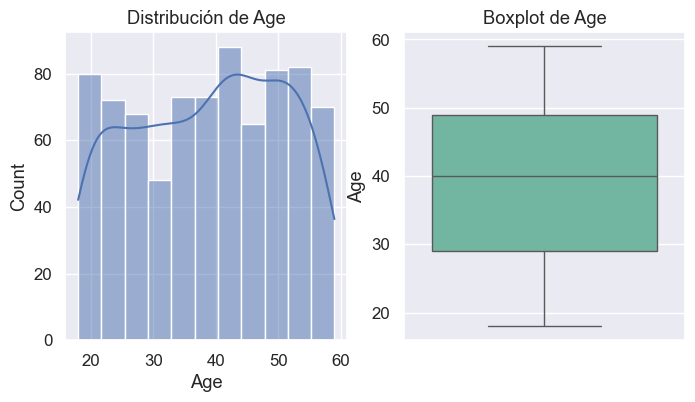

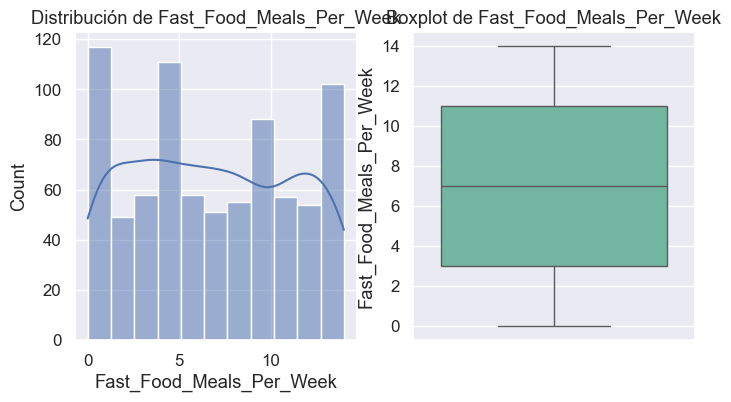

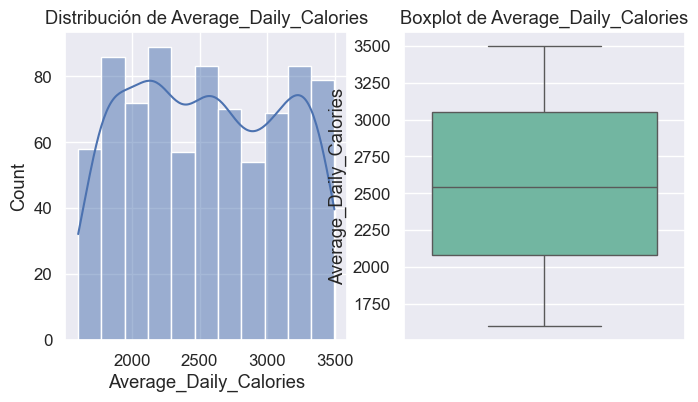

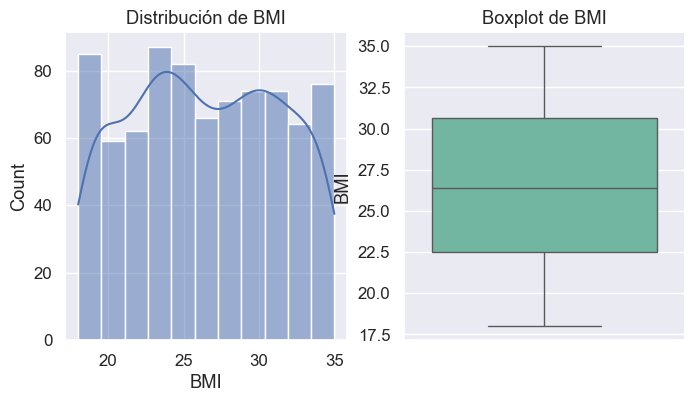

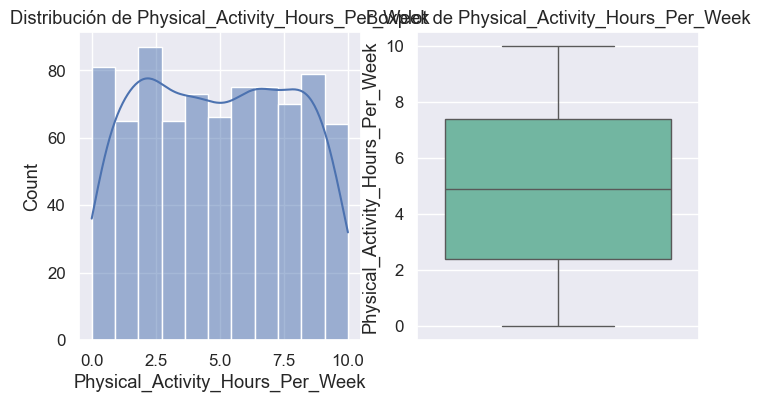

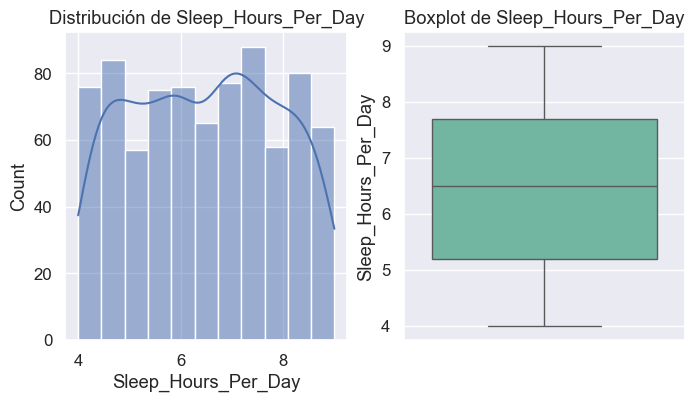

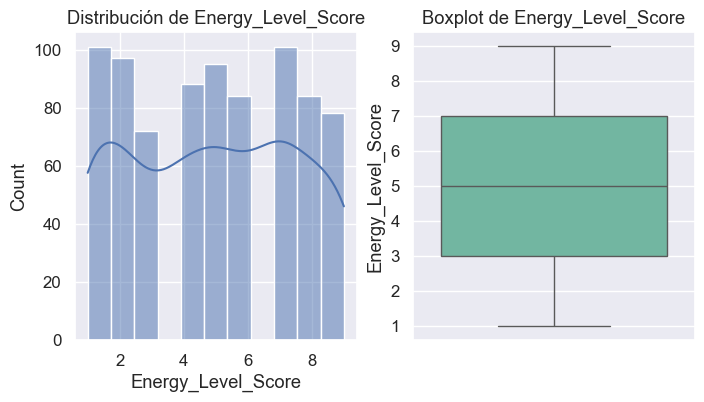

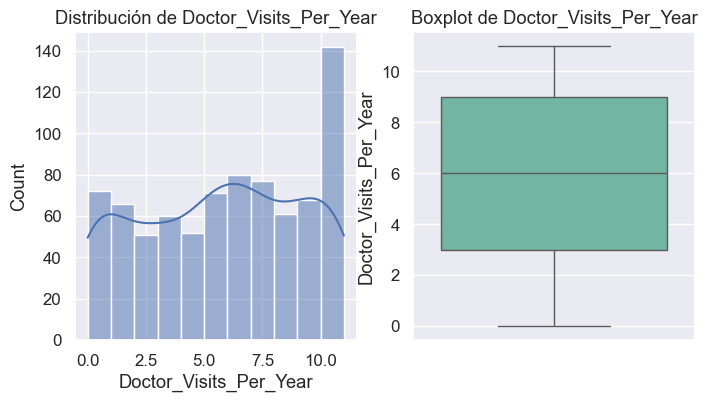

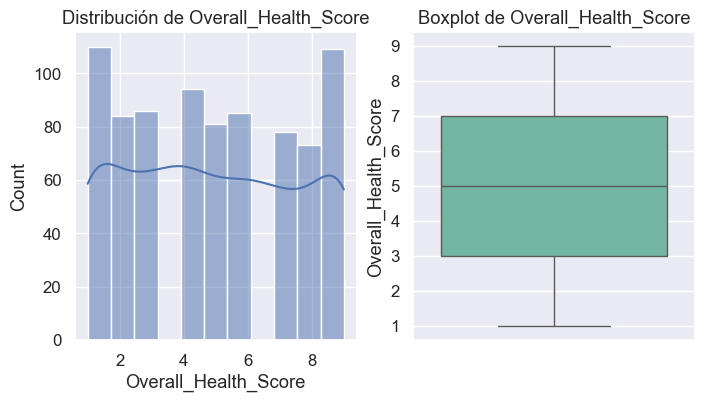

In [10]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribución de {col}')

    plt.subplot(1,2,2)
    sns.boxplot(y=df[col],palette='Set2')
    plt.title(f'Boxplot de {col}')
    plt.show

In [11]:
print(f'La mayoría de participantes tienen edad {df['Age'].value_counts().head(1)}')
df['Age'].value_counts().head()

La mayoría de participantes tienen edad Age
45    28
Name: count, dtype: int64


Age
45    28
43    28
50    27
52    27
49    25
Name: count, dtype: int64

distribución de Gender:
Gender
Male      0.48125
Female    0.47625
Other     0.04250
Name: proportion, dtype: float64


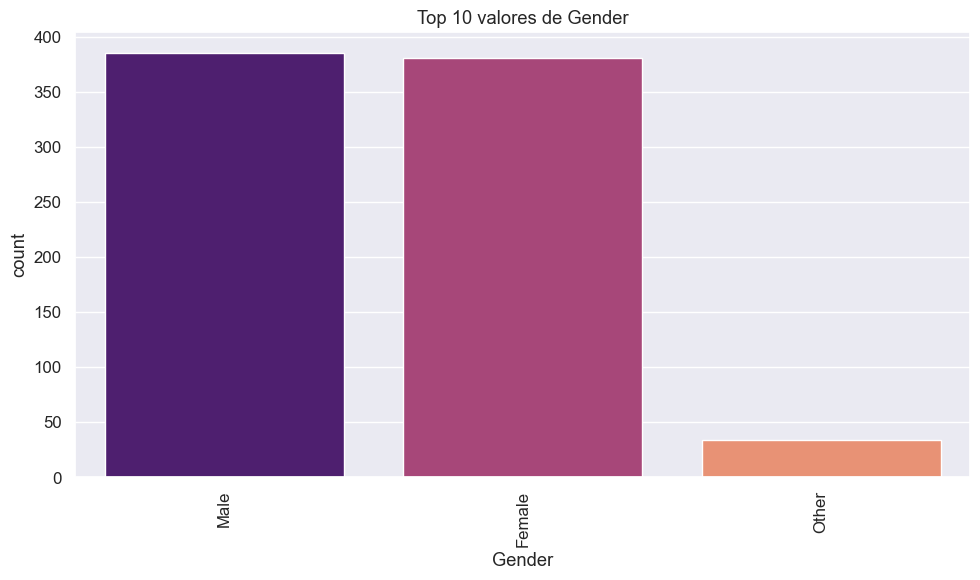

distribución de Digestive_Issues:
Digestive_Issues
No     0.62125
Yes    0.37875
Name: proportion, dtype: float64


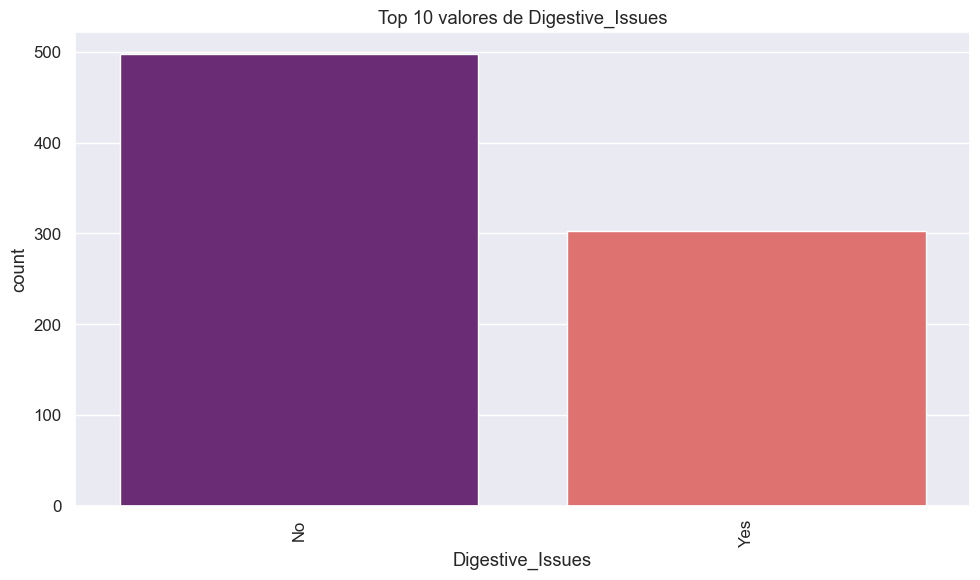

In [12]:
for column in cat_cols:
    print(f'distribución de {column}:')
    print(df[column].value_counts(normalize=True).head(10))

    top_cat=df[column].value_counts().head(10).index.tolist()

    temp_filt=df[df[column].isin(top_cat)].copy()

     # Crear el gráfico
    plt.figure(figsize=(10, 6))
    
    # Ordenar las categorías por frecuencia (opcional pero recomendado)
    order = temp_filt[column].value_counts().index
    
    sns.countplot(x=column, data=temp_filt, order=order,palette='magma')
    plt.xticks(rotation=90)
    plt.title(f'Top 10 valores de {column}')
    plt.tight_layout()
    plt.show()

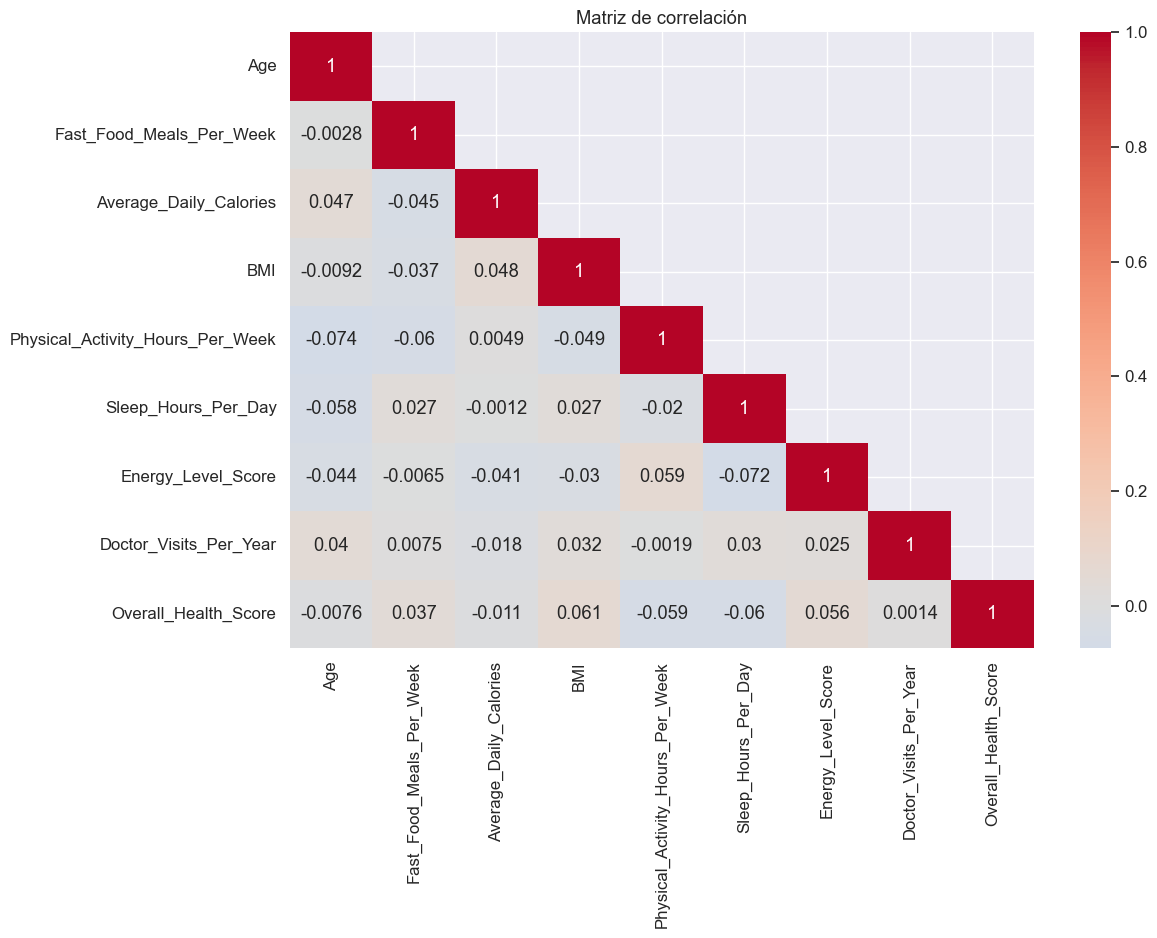

In [13]:
mask = np.triu(np.ones_like(num_cols.corr(),dtype = bool),k=1)

plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(), mask = mask, annot=True, cmap='coolwarm',center=0)
plt.title('Matriz de correlación')
plt.show()

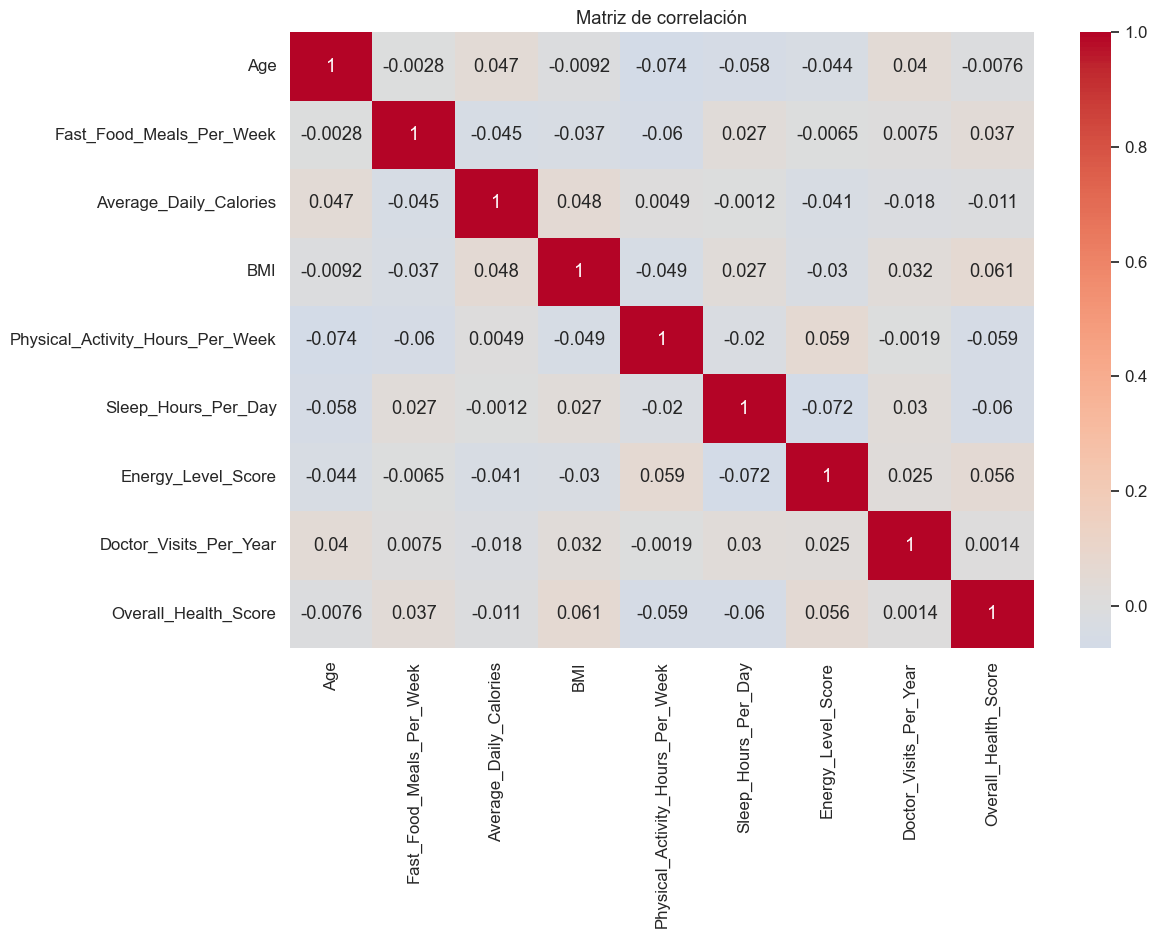

In [14]:
if len(num_cols)>1:
    plt.figure(figsize=(12,8))
    sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm',center=0)
    plt.title('Matriz de correlación')
    plt.show()

In [15]:
#Se cambia l tipo de datos de las columnas 'Gender' y 'Digestive_Issues' a tipo categórico

df['Gender']=df['Gender'].astype('category')
df['Digestive_Issues']=df['Digestive_Issues'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    category
 2   Fast_Food_Meals_Per_Week          800 non-null    int64   
 3   Average_Daily_Calories            800 non-null    int64   
 4   BMI                               800 non-null    float64 
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64 
 6   Sleep_Hours_Per_Day               800 non-null    float64 
 7   Energy_Level_Score                800 non-null    int64   
 8   Digestive_Issues                  800 non-null    category
 9   Doctor_Visits_Per_Year            800 non-null    int64   
 10  Overall_Health_Score              800 non-null    int64   
dtypes: category(2), float64(3), int64(6)
memory usage: 58.1 KB


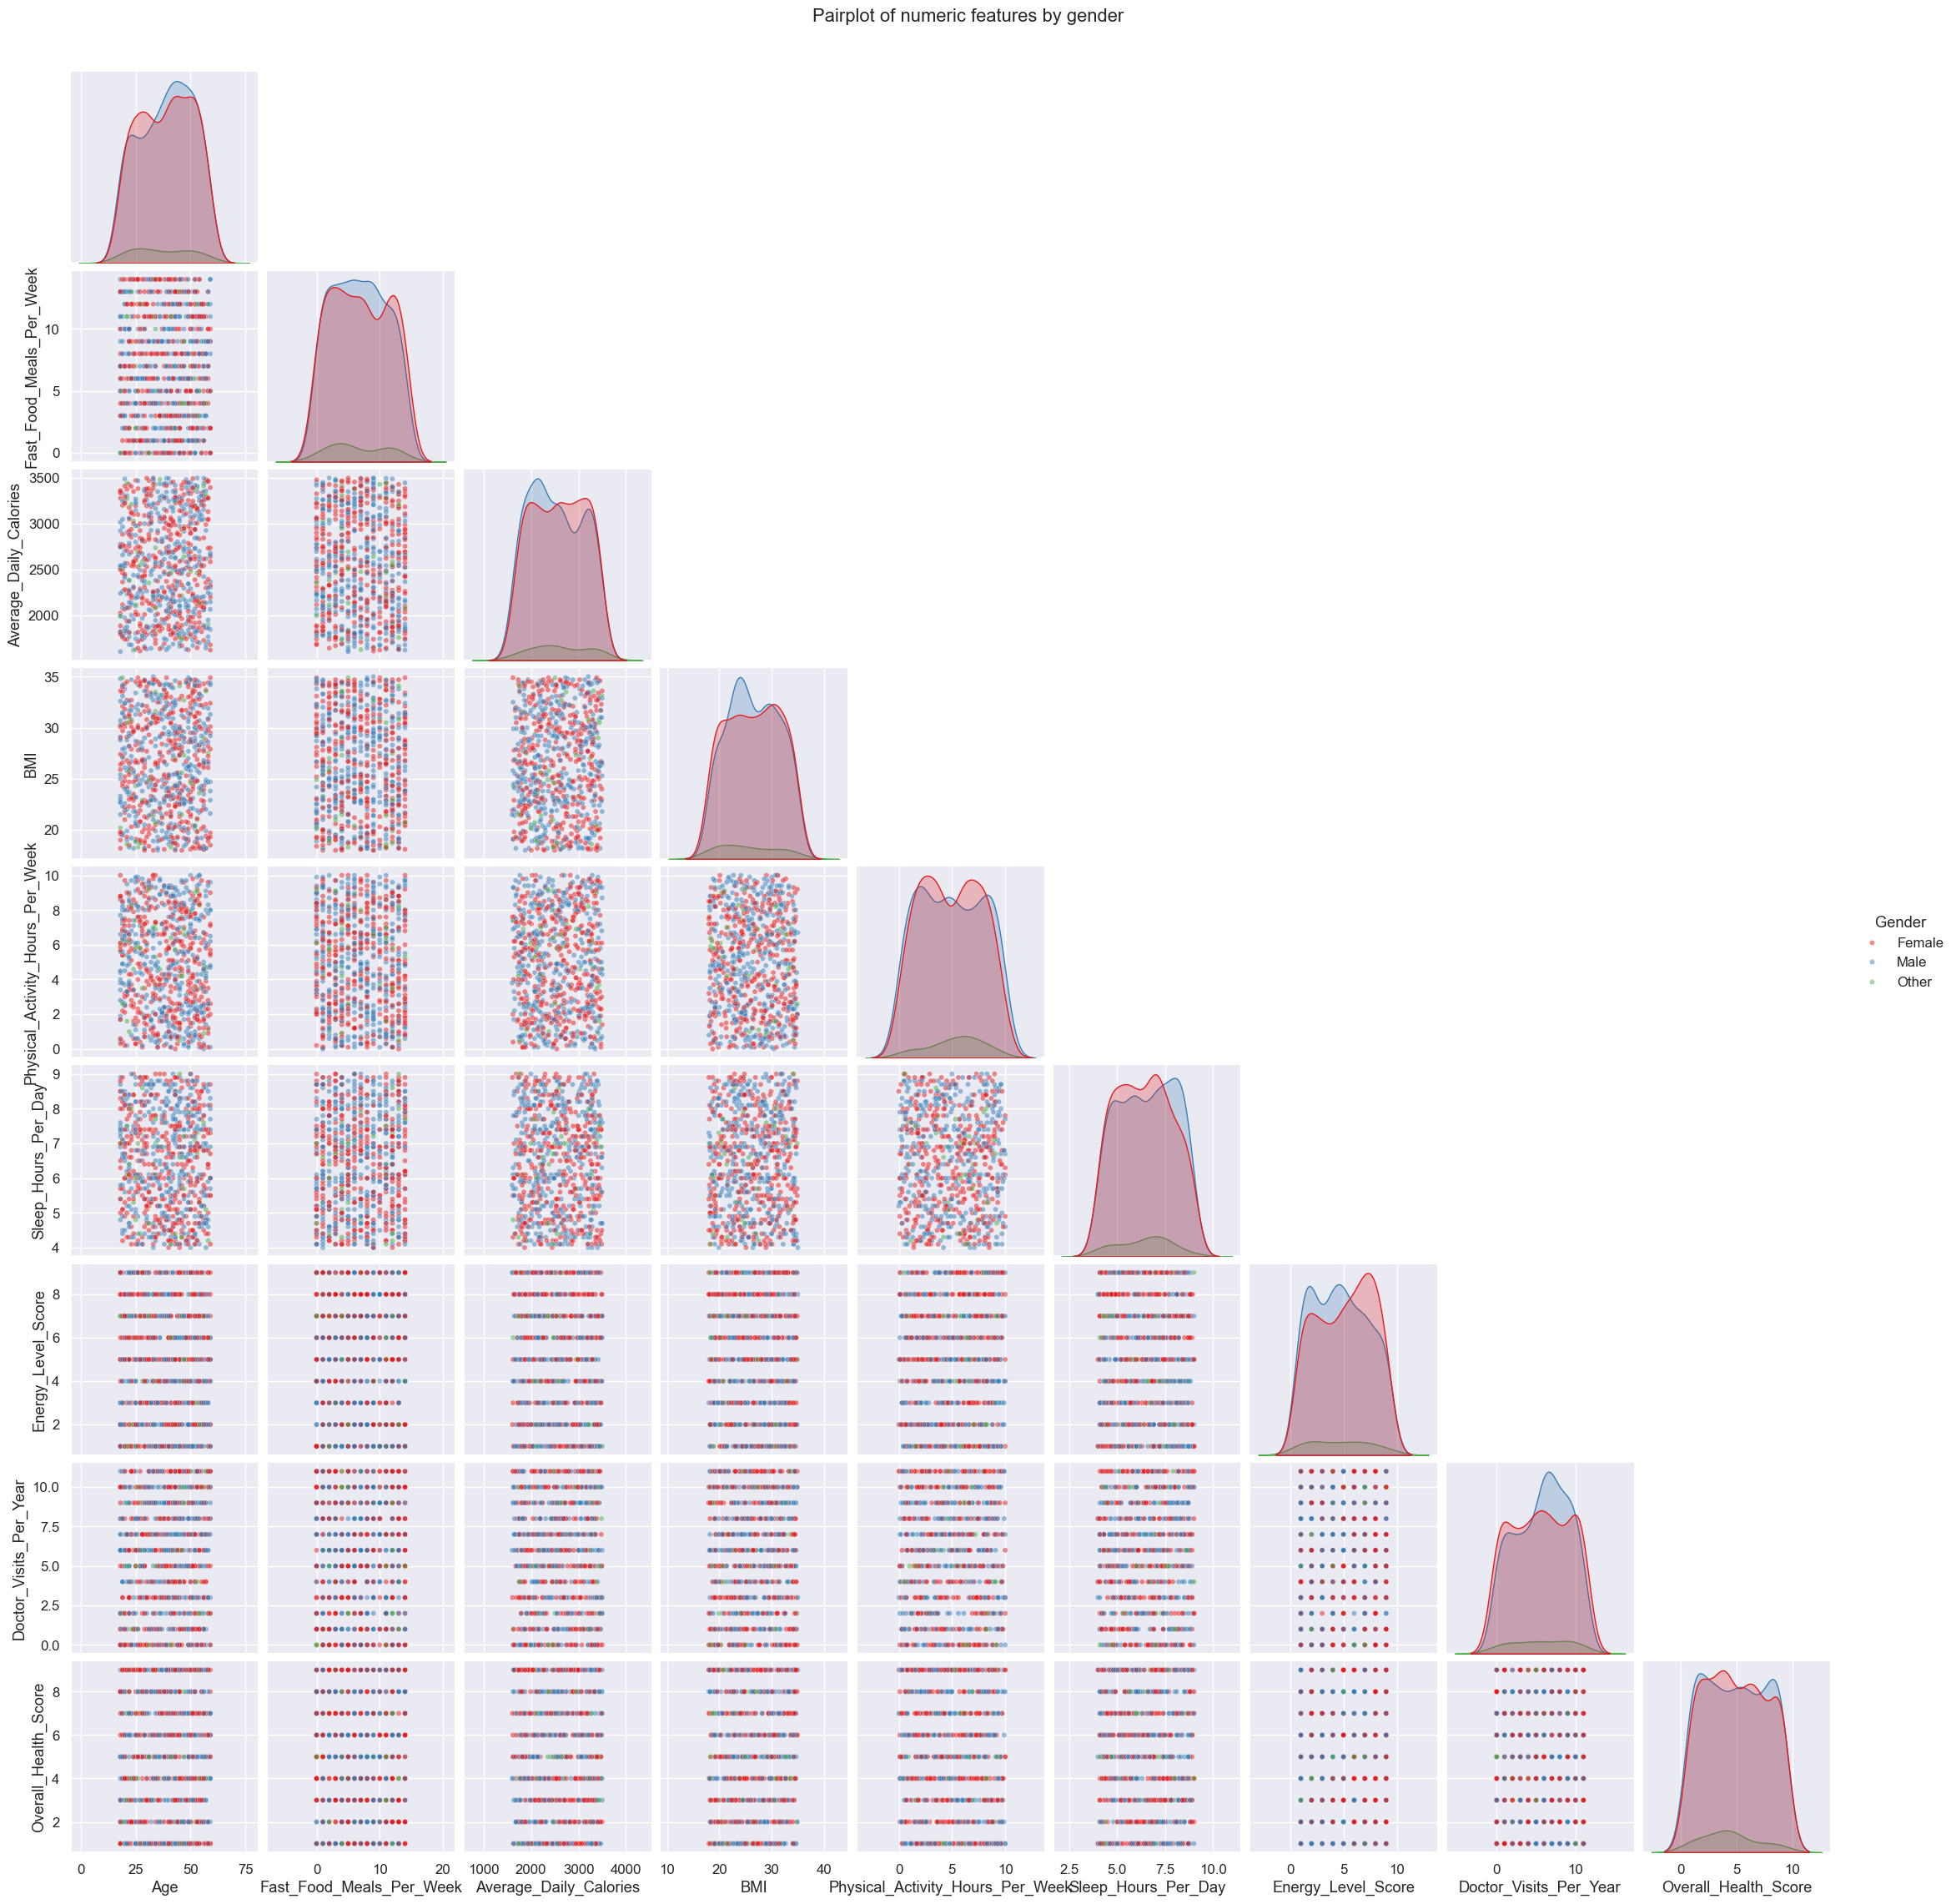

In [16]:

sns.pairplot(df, vars=num_cols, hue='Gender', palette='Set1', diag_kind='kde', corner = True, plot_kws={'alpha':0.5, 's':20})

plt.suptitle('Pairplot of numeric features by gender', y=1.02)
plt.show()

No se observan patrones claros en el pairplot que nos pueda dar información acerca del comportamiento de las variables dependiendo del género 

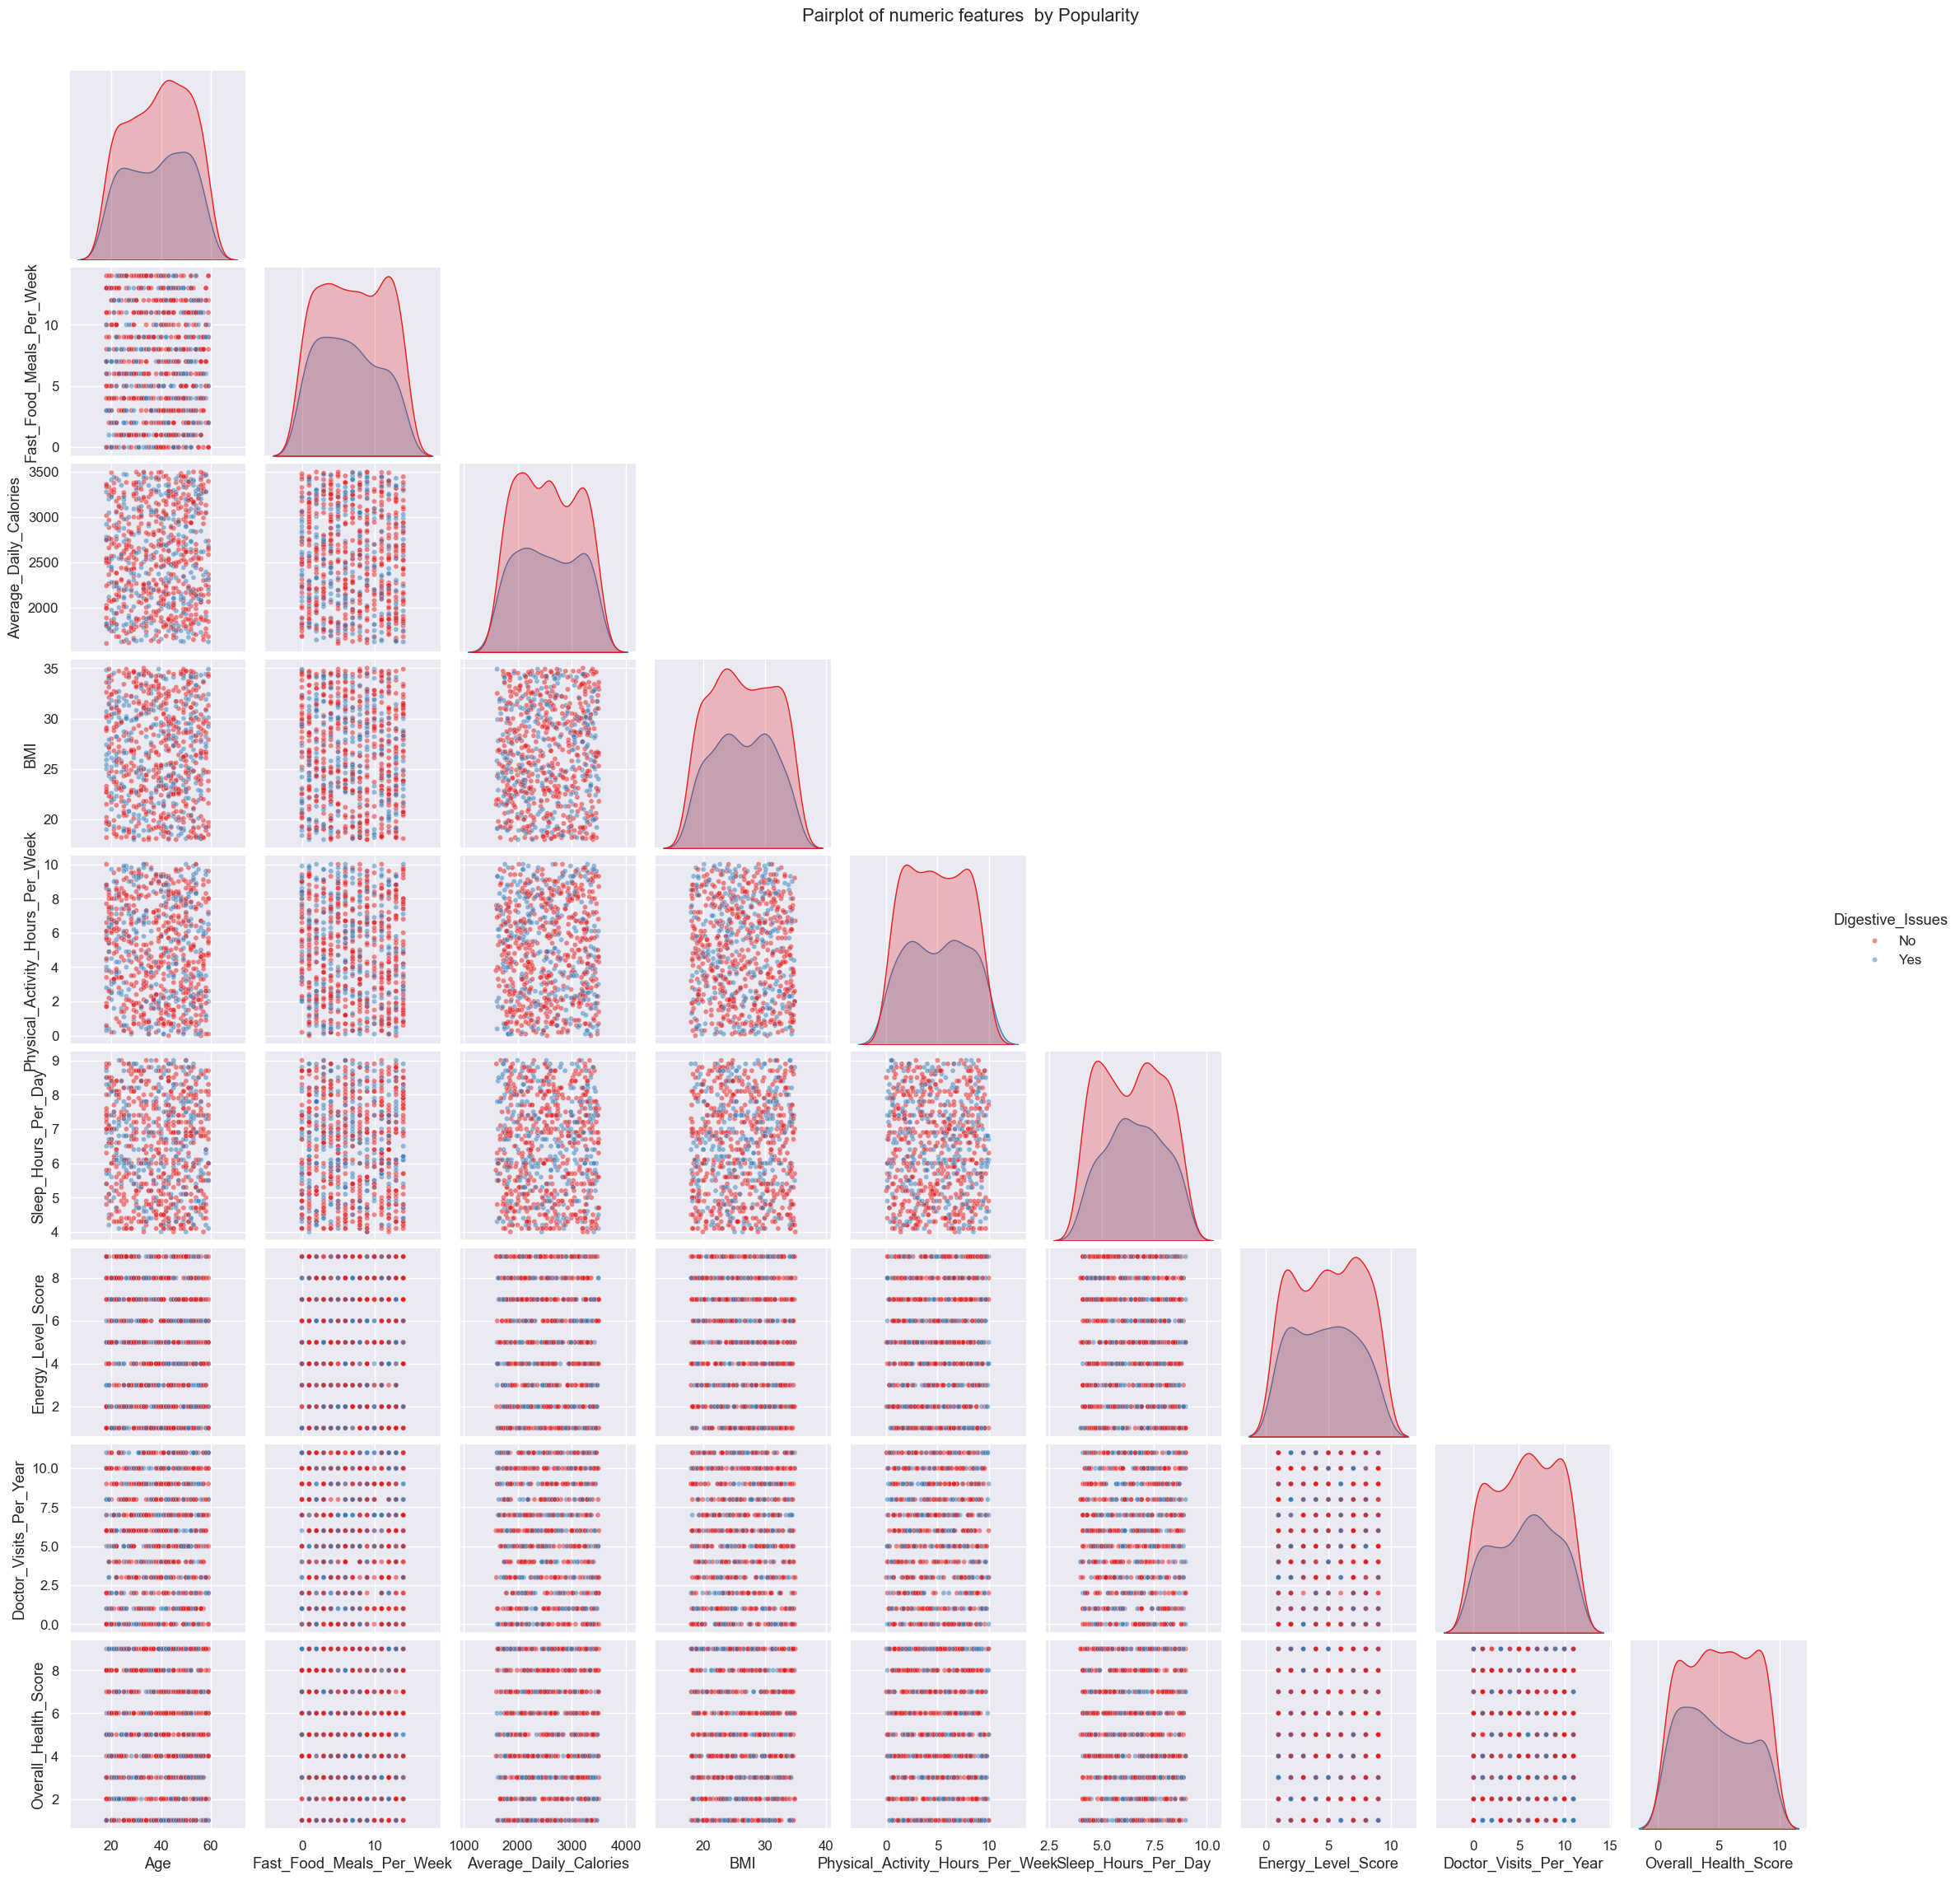

In [17]:

sns.pairplot(df, corner= True, vars=num_cols, hue='Digestive_Issues', palette='Set1', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})

plt.suptitle('Pairplot of numeric features  by Popularity', y=1.02)
plt.show()

No se observan patrones claros que relacionen las variables con los problemas digestivos.

SE PLANTEAN ALGUNAS CUESTIONES DE INTERÉS RELACIONADAS CON LOS DATOS ESTUDIADOS

La columna con datos de mayor interés es el puntaje de salud (Overall_health_score)

Qué sección de la población de estudio tiene mayor puntaje de salud?

las personas con mayor actividad física tienen mejor puntaje de salud?

se relacionan directamente la cantidad de comidas rápidas por semana, así como las calorías promedio diarias con el puntaje de salud?



In [18]:
print(df.columns.tolist())

['Age', 'Gender', 'Fast_Food_Meals_Per_Week', 'Average_Daily_Calories', 'BMI', 'Physical_Activity_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'Energy_Level_Score', 'Digestive_Issues', 'Doctor_Visits_Per_Year', 'Overall_Health_Score']


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    category
 2   Fast_Food_Meals_Per_Week          800 non-null    int64   
 3   Average_Daily_Calories            800 non-null    int64   
 4   BMI                               800 non-null    float64 
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64 
 6   Sleep_Hours_Per_Day               800 non-null    float64 
 7   Energy_Level_Score                800 non-null    int64   
 8   Digestive_Issues                  800 non-null    category
 9   Doctor_Visits_Per_Year            800 non-null    int64   
 10  Overall_Health_Score              800 non-null    int64   
dtypes: category(2), float64(3), int64(6)
memory usage: 58.1 KB


In [20]:
ohs_age=df[['Overall_Health_Score','Age']]
#sns.barplot(ohs_age,x='Overall_Health_Score',y='Age',palette='Set1')
#sns.histplot(ohs_age['Overall_Health_Score'],kde=True,palette='Set3')
ohs_age.value_counts()

Overall_Health_Score  Age
9                     33     7
                      39     7
3                     32     6
5                     31     6
8                     18     6
                            ..
                      49     1
5                     22     1
3                     23     1
7                     39     1
                      45     1
Name: count, Length: 334, dtype: int64

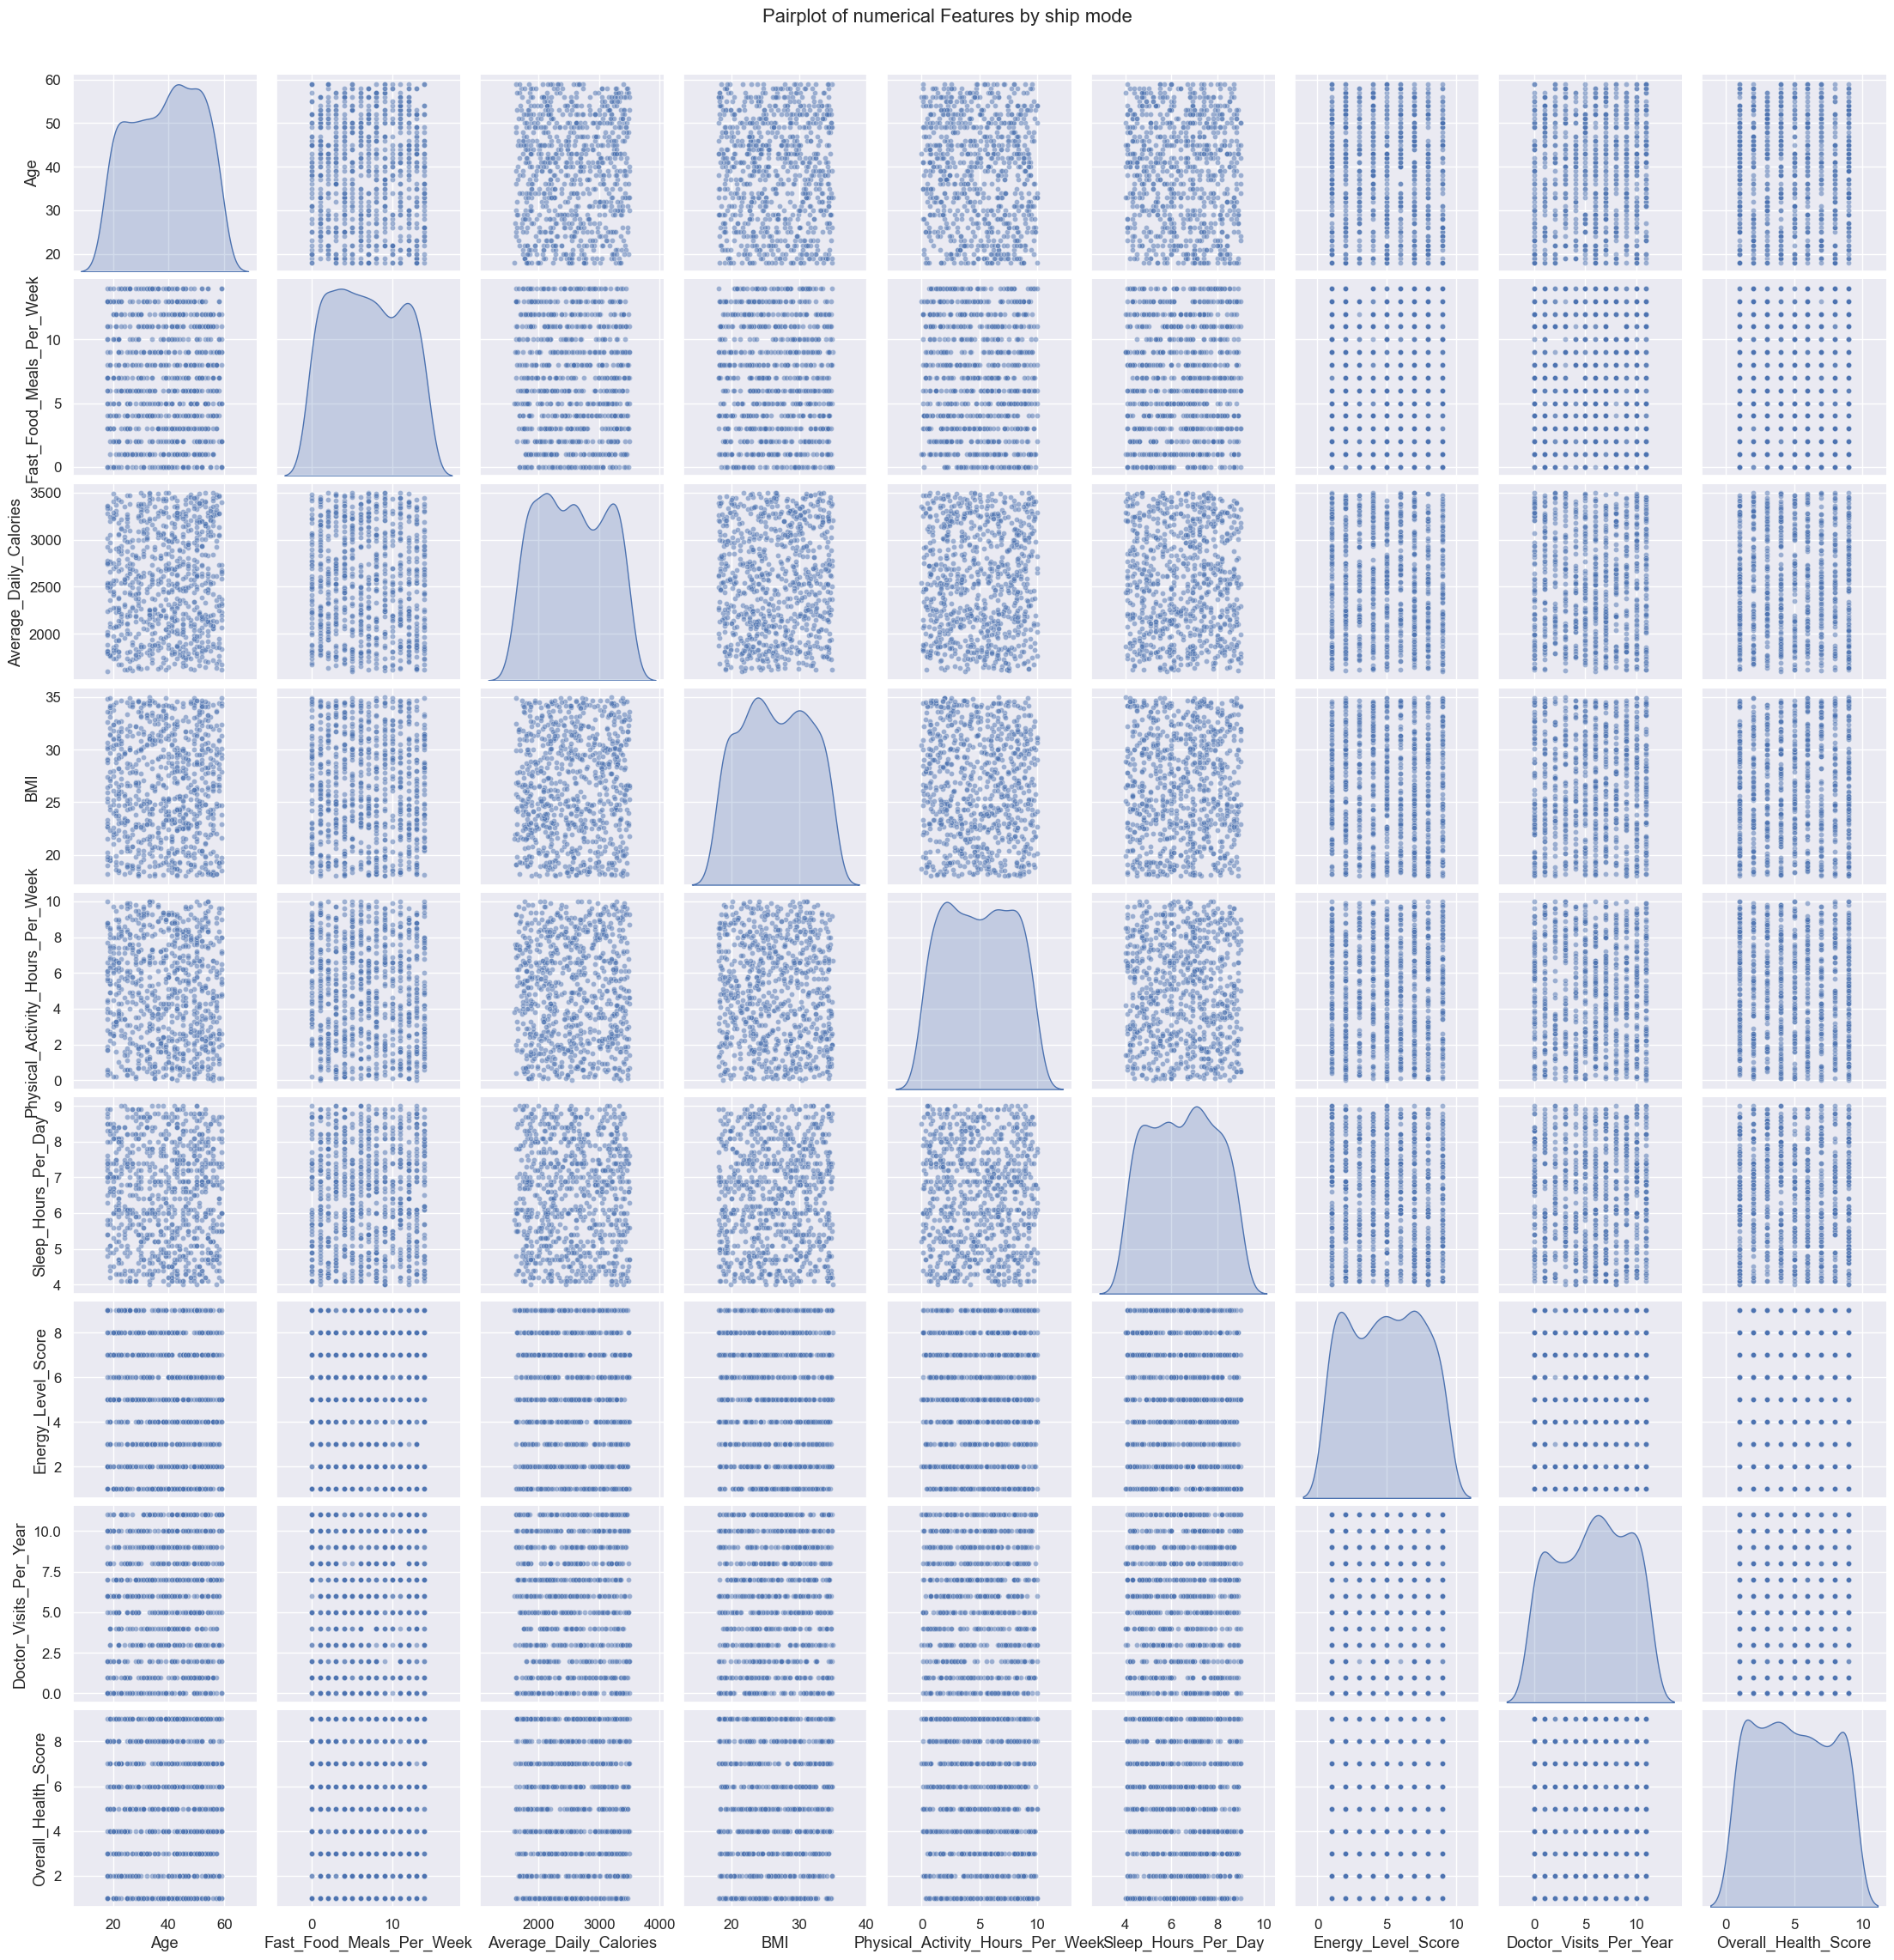

In [21]:
sns.pairplot(df.select_dtypes(include=['int64','float64']), palette='Set1', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})

plt.suptitle('Pairplot of numerical Features by ship mode', y=1.02)
plt.show()

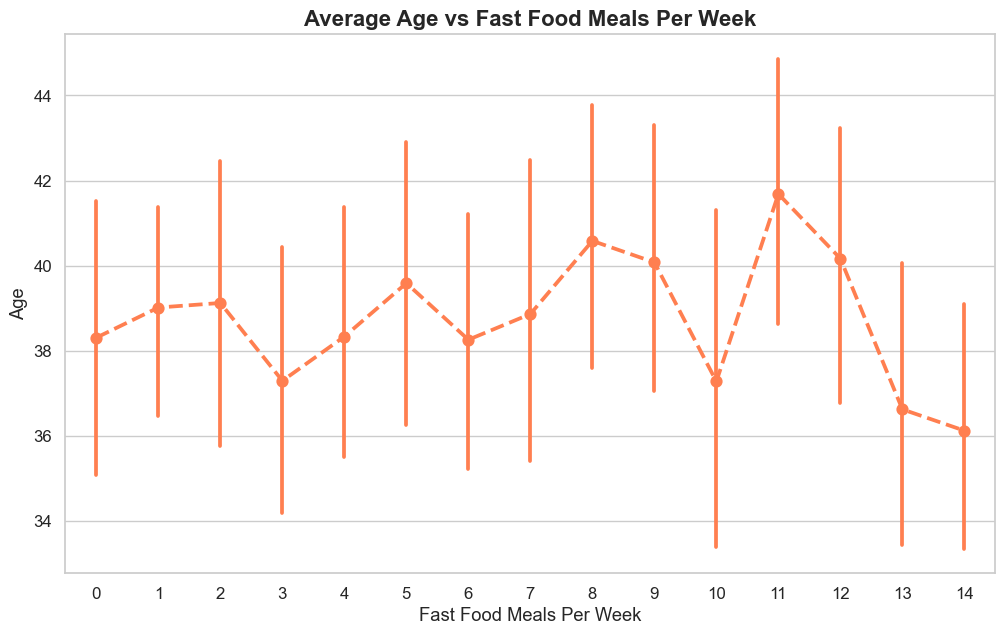

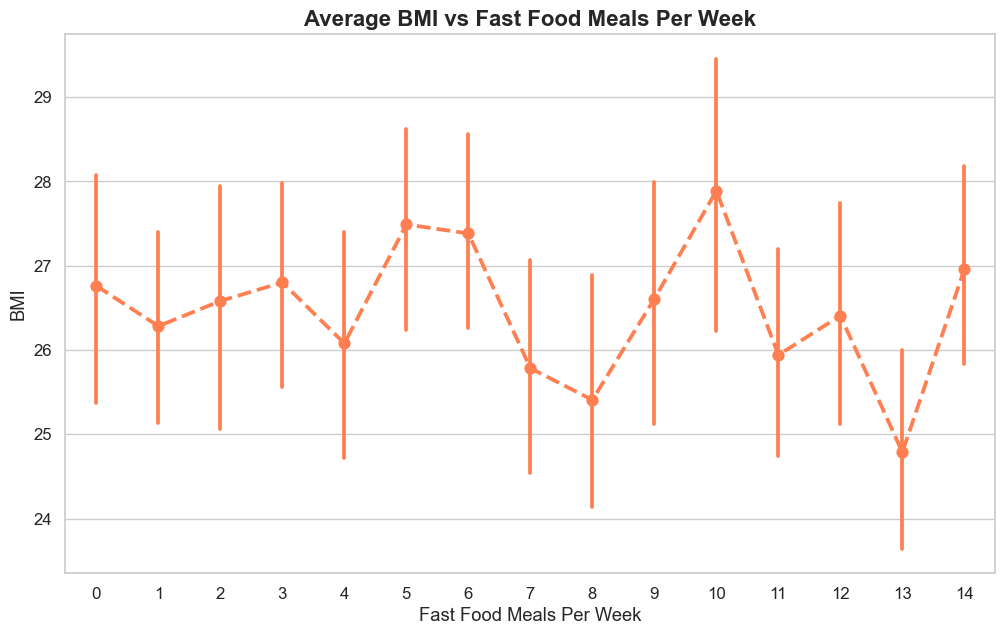

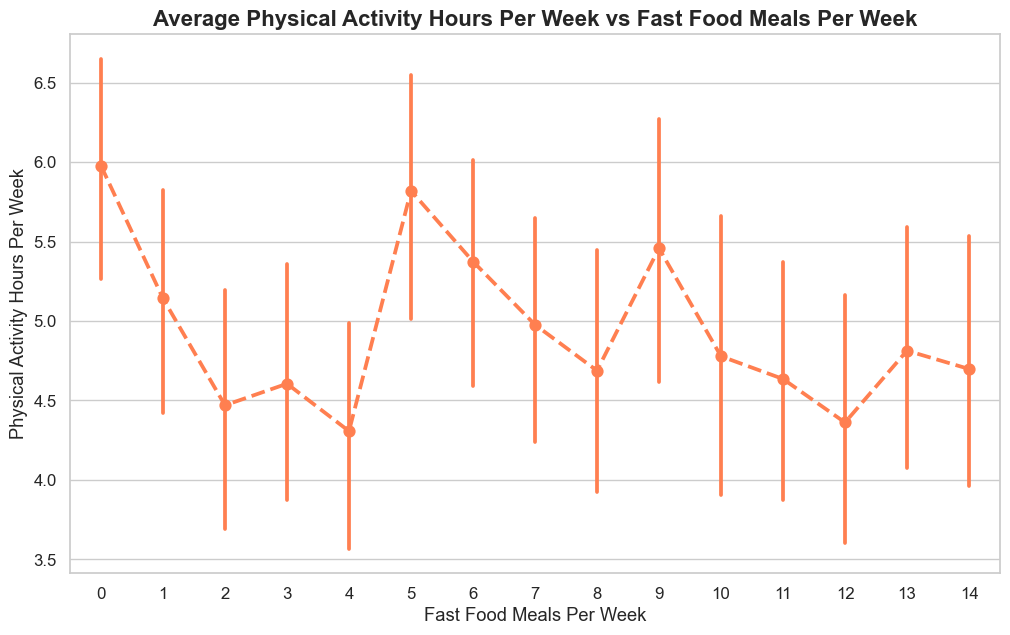

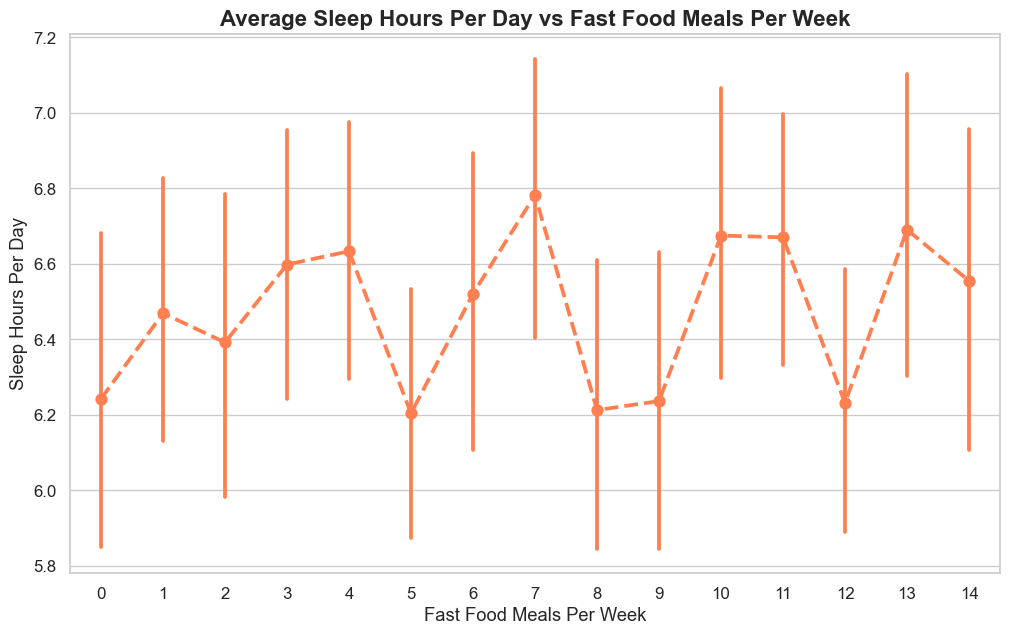

In [22]:
cols=['Age','BMI','Physical_Activity_Hours_Per_Week','Sleep_Hours_Per_Day']

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

for col in cols:
    plt.figure()
    sns.pointplot(data=df,x='Fast_Food_Meals_Per_Week',y=col, errorbar='ci',color='coral', markers='o', linestyles='--')

    plt.title(f'Average {col.replace("_", " ")} vs Fast Food Meals Per Week',
              fontsize=16, fontweight='bold')
    plt.xlabel('Fast Food Meals Per Week')
    plt.ylabel(col.replace('_', ' '))
   
    
    plt.show()

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    category
 2   Fast_Food_Meals_Per_Week          800 non-null    int64   
 3   Average_Daily_Calories            800 non-null    int64   
 4   BMI                               800 non-null    float64 
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64 
 6   Sleep_Hours_Per_Day               800 non-null    float64 
 7   Energy_Level_Score                800 non-null    int64   
 8   Digestive_Issues                  800 non-null    category
 9   Doctor_Visits_Per_Year            800 non-null    int64   
 10  Overall_Health_Score              800 non-null    int64   
dtypes: category(2), float64(3), int64(6)
memory usage: 58.1 KB


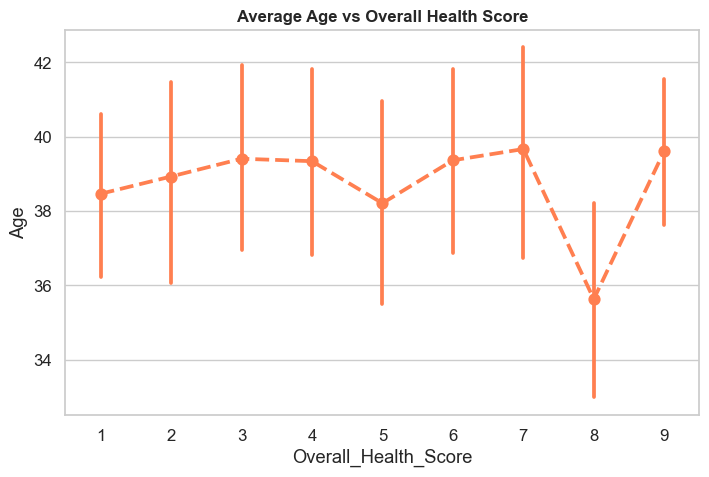

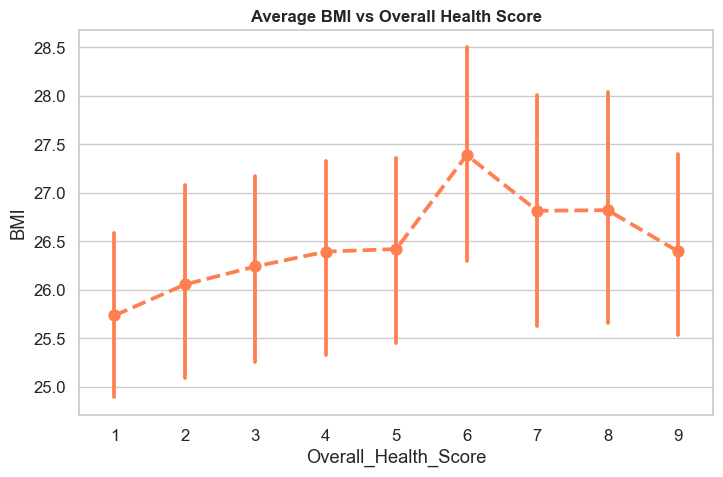

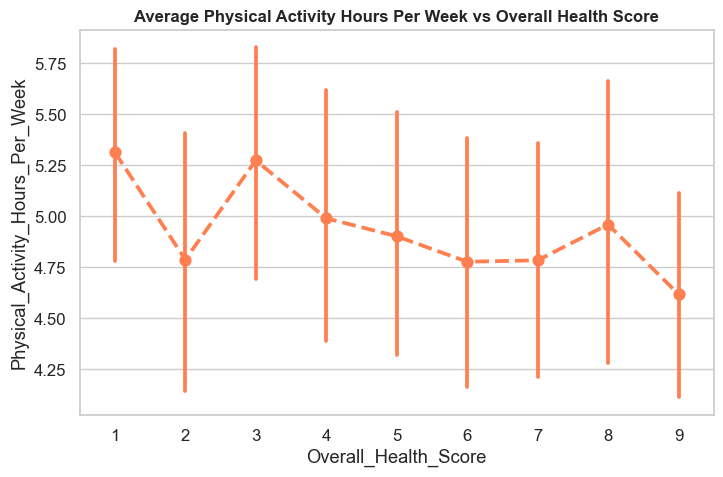

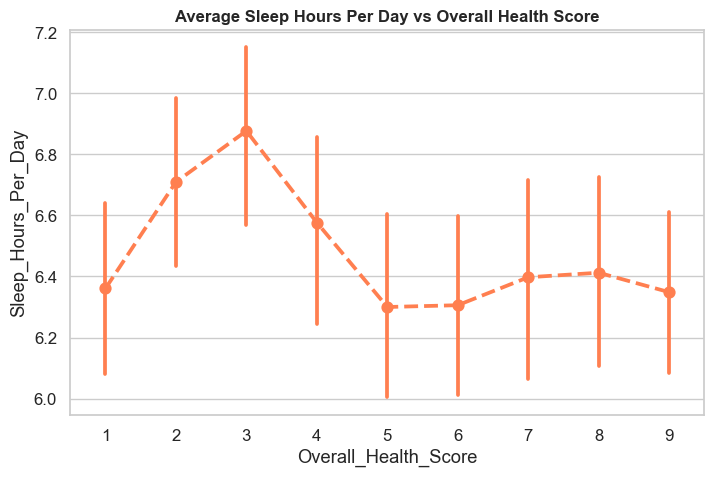

In [24]:
for col in cols:
    plt.figure(figsize=(18,5))
    plt.subplot(1,2,1)
    sns.pointplot(data=df,x='Overall_Health_Score',y=col, errorbar='ci',color='coral', markers='o', linestyles='--')

    plt.title(f'Average {col.replace("_", " ")} vs Overall Health Score',fontsize=12, fontweight='bold')

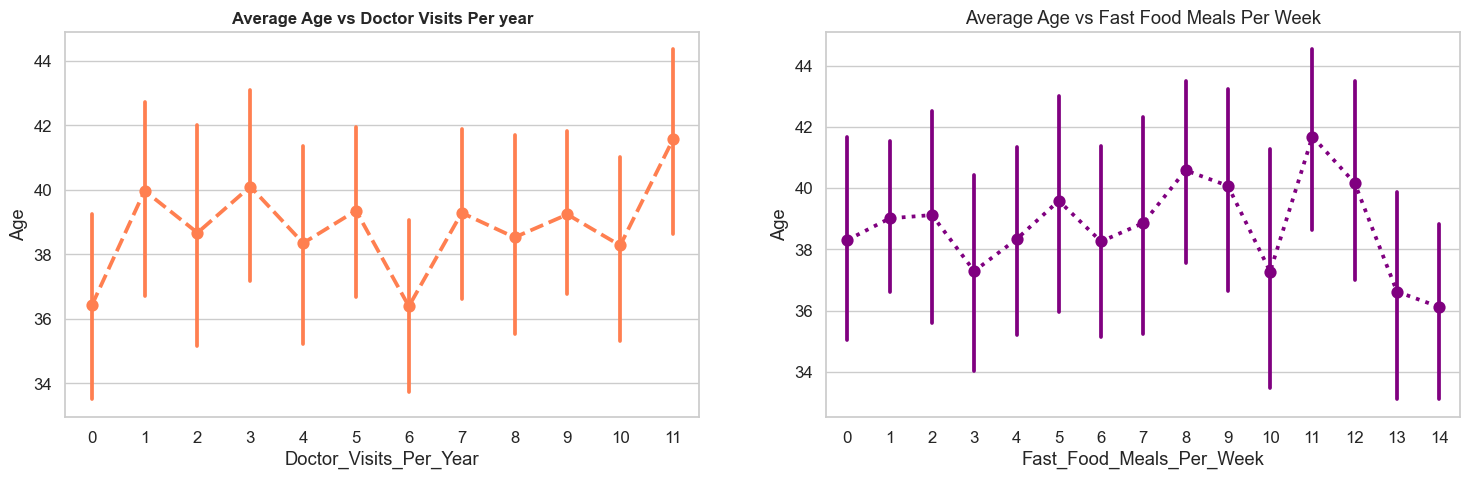

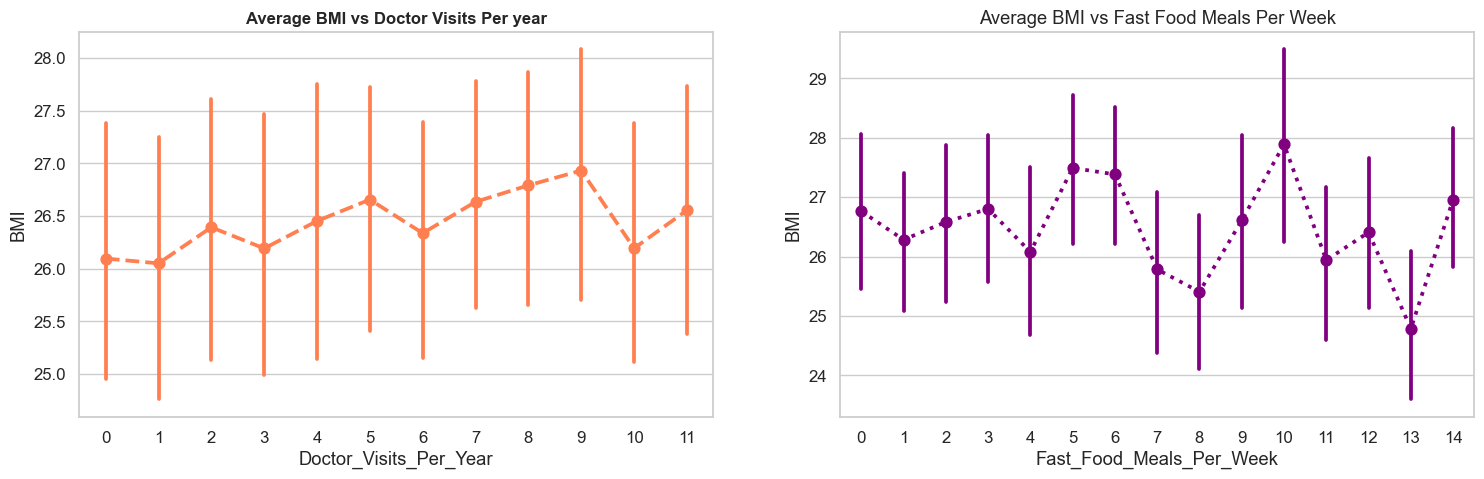

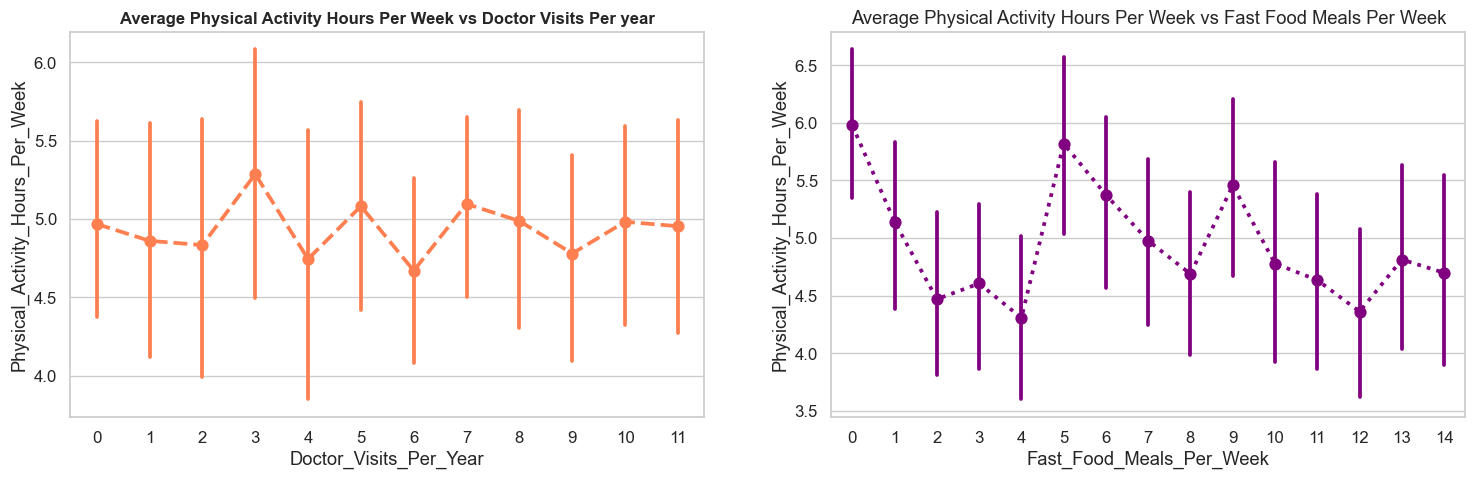

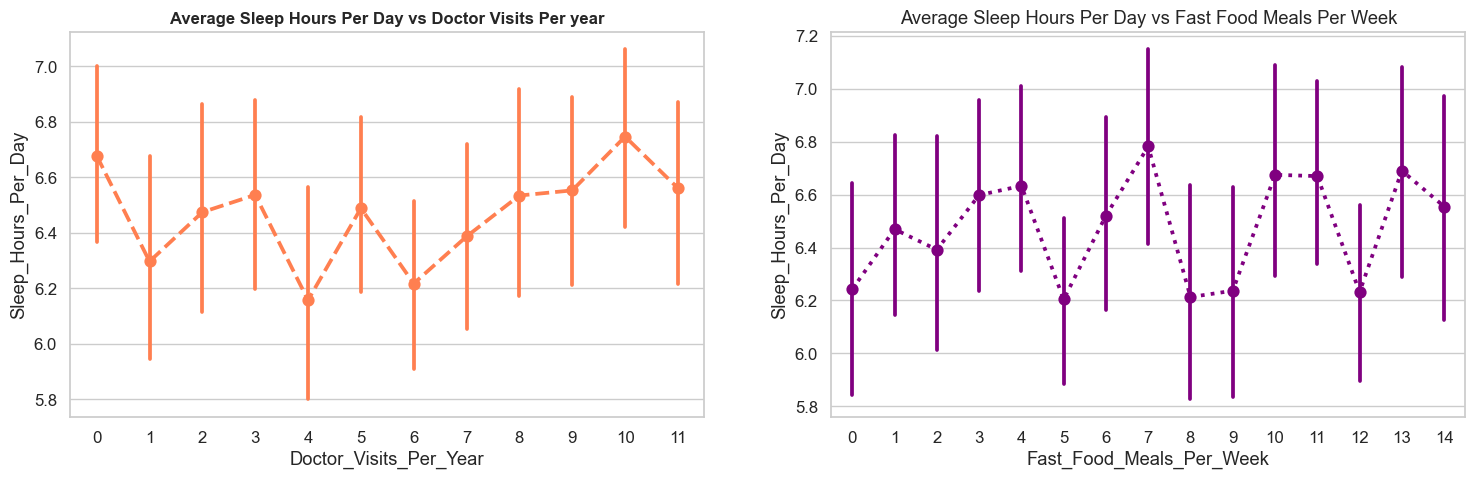

In [25]:
for col in cols:
    plt.figure(figsize=(18,5))
    plt.subplot(1,2,1)
    sns.pointplot(data=df,x='Doctor_Visits_Per_Year',y=col, errorbar='ci',color='coral', markers='o', linestyles='--')

    plt.title(f'Average {col.replace("_", " ")} vs Doctor Visits Per year',
              fontsize=12, fontweight='bold')
    plt.subplot(1,2,2)
    sns.pointplot(data=df,x='Fast_Food_Meals_Per_Week',y=col, color='purple', markers='o', linestyles='dotted')
    plt.title(f'Average {col.replace("_", " ")} vs Fast Food Meals Per Week')
    plt.show()

=========== DISTRIBUCIÓN DE FRECUENCIAS ==================


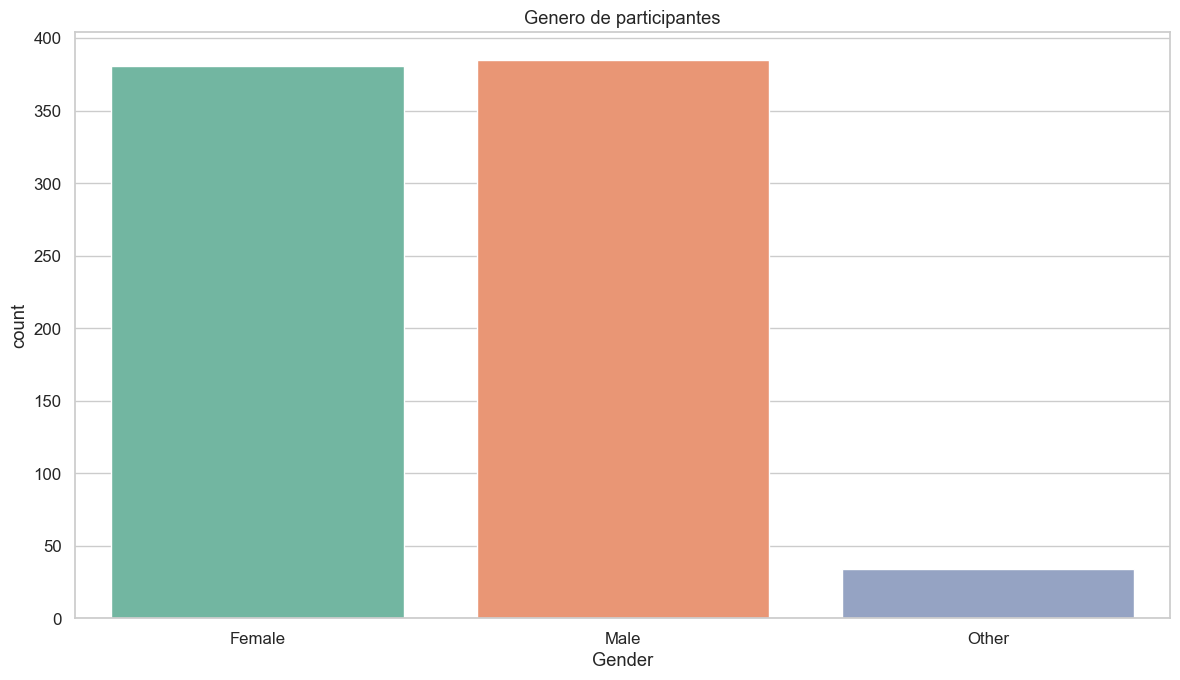

In [26]:
plt.figure()
sns.countplot(data=df,x='Gender',palette='Set2')
plt.title('Genero de participantes')
plt.xlabel('Gender')
plt.ylabel('count')
plt.tight_layout()
plt.show()

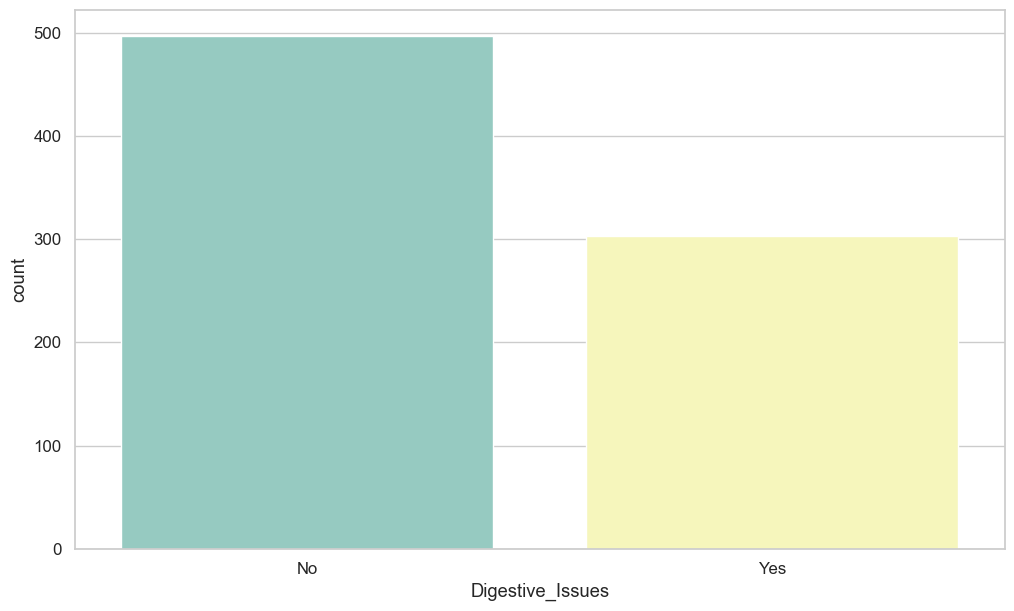

In [27]:
plt.figure()
sns.countplot(data=df,x='Digestive_Issues',palette='Set3')
#sns.title('Participantes con problemas digestivos')
plt.show()

========== GRÁFICAS DE BARRAS ========


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    category
 2   Fast_Food_Meals_Per_Week          800 non-null    int64   
 3   Average_Daily_Calories            800 non-null    int64   
 4   BMI                               800 non-null    float64 
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64 
 6   Sleep_Hours_Per_Day               800 non-null    float64 
 7   Energy_Level_Score                800 non-null    int64   
 8   Digestive_Issues                  800 non-null    category
 9   Doctor_Visits_Per_Year            800 non-null    int64   
 10  Overall_Health_Score              800 non-null    int64   
dtypes: category(2), float64(3), int64(6)
memory usage: 58.1 KB


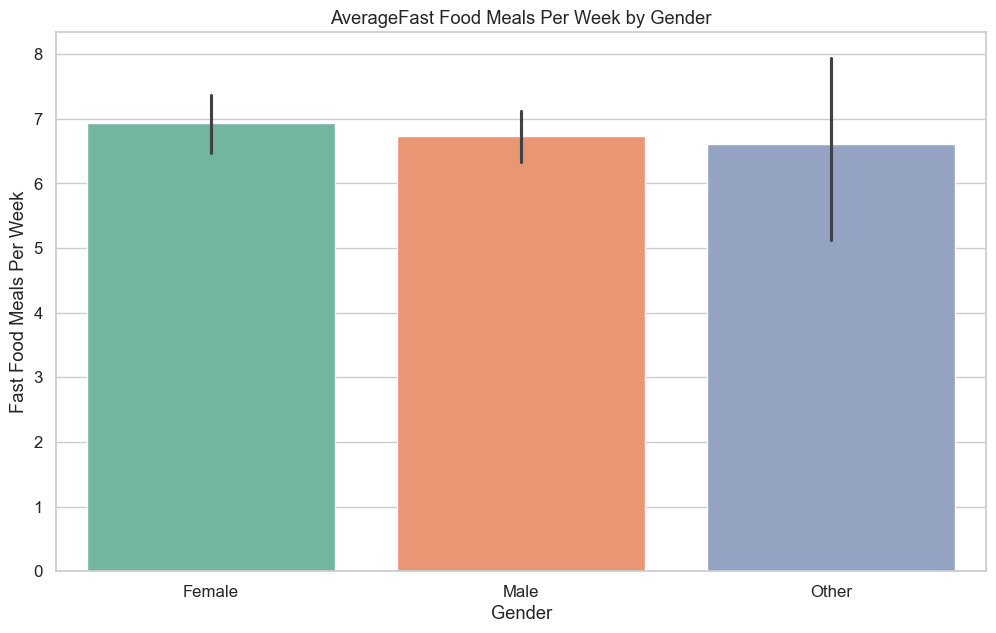

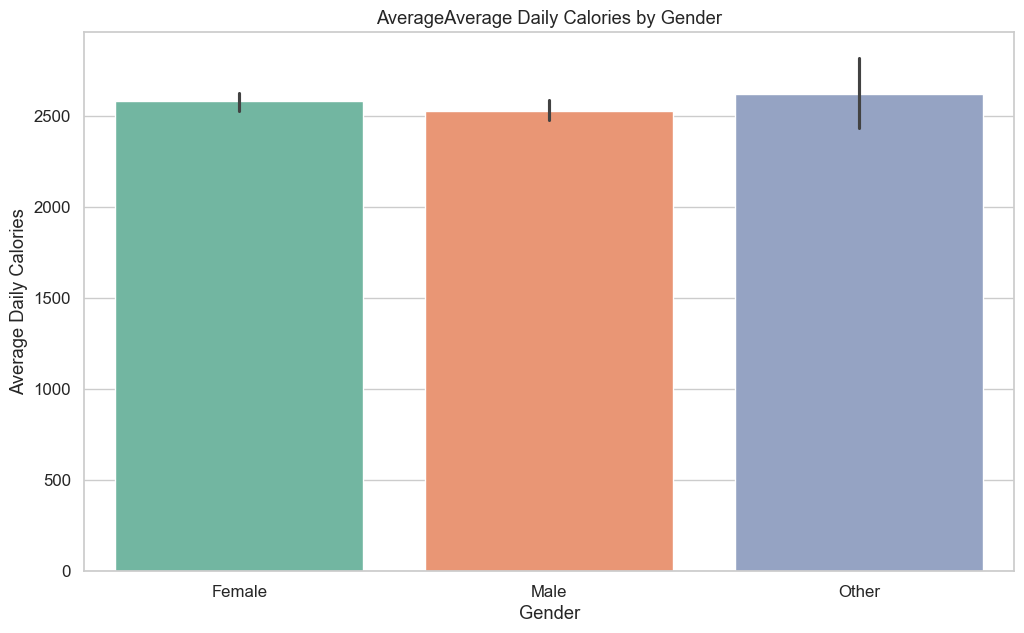

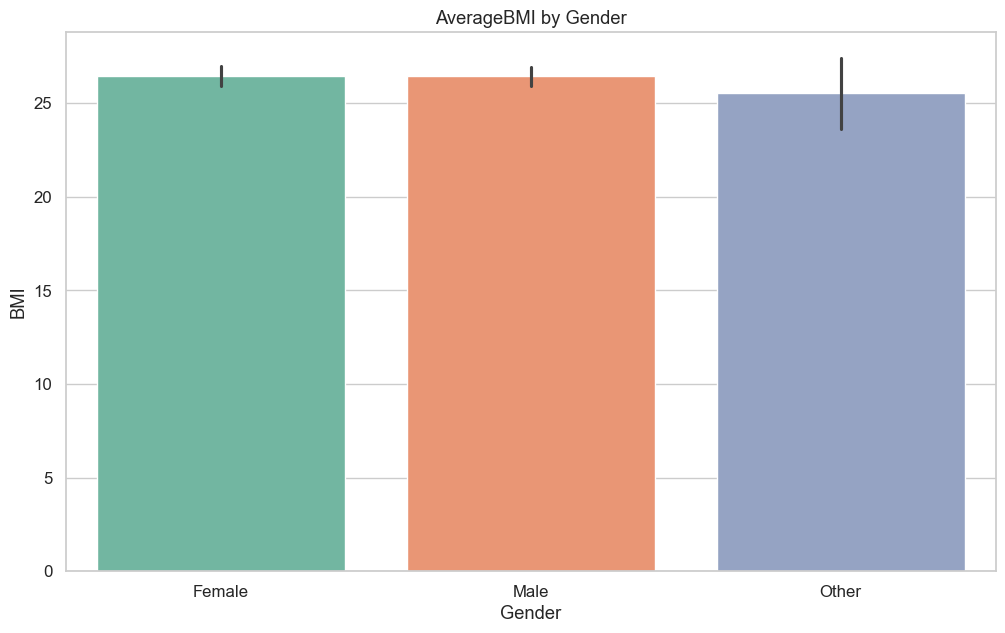

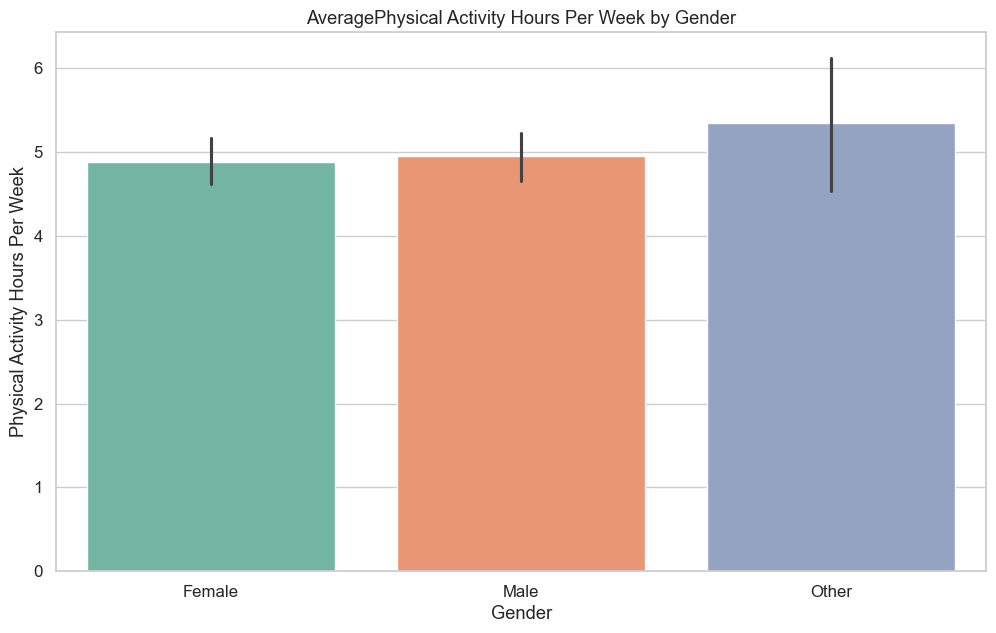

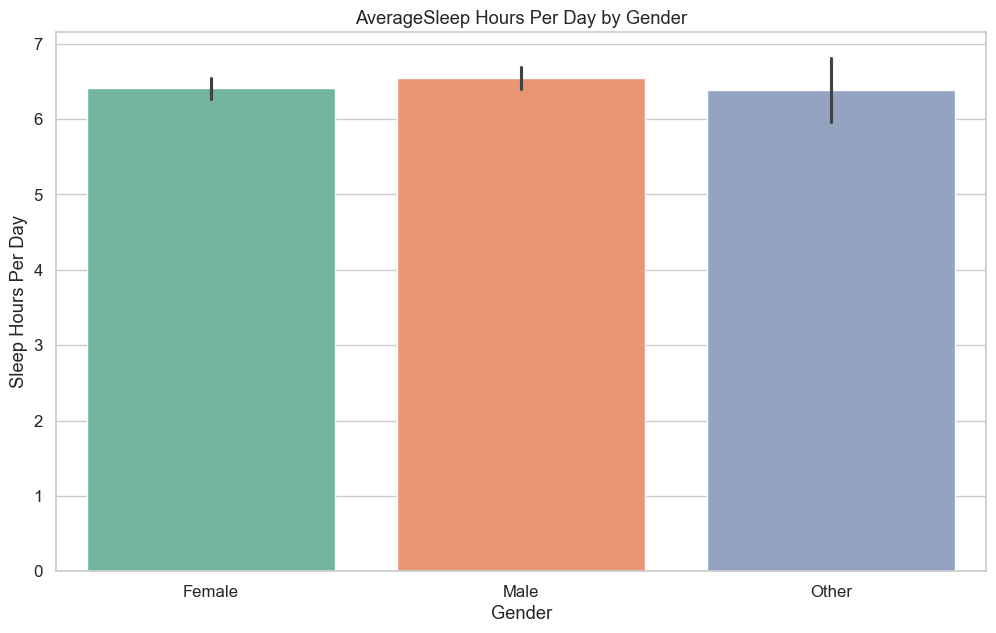

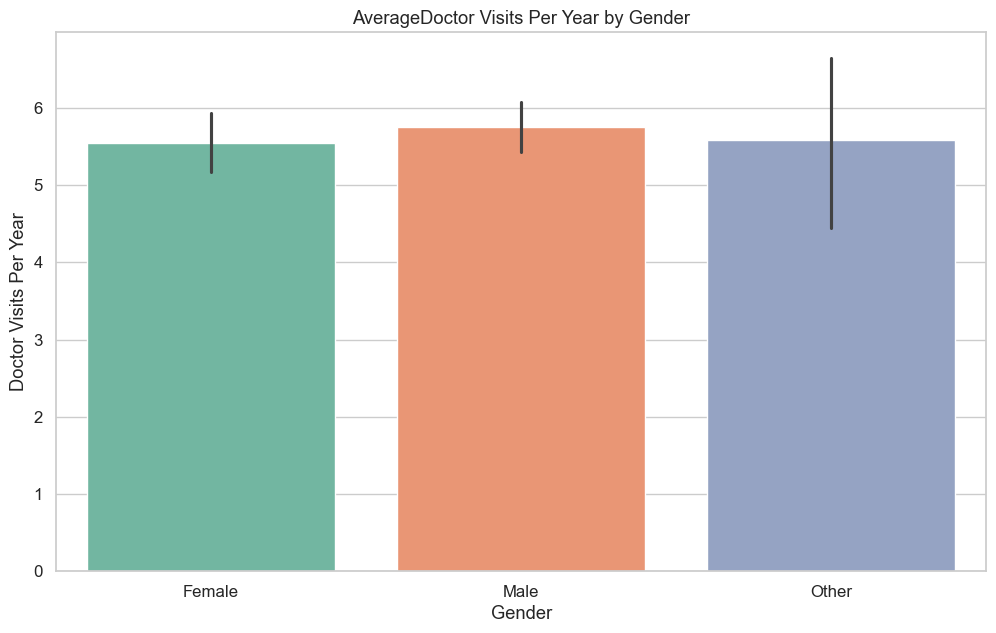

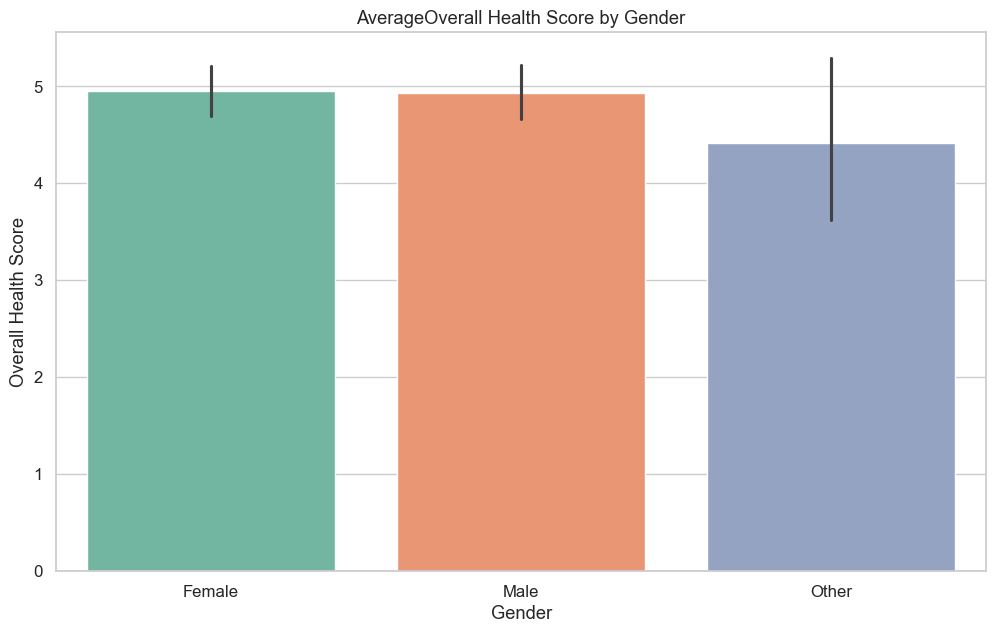

In [29]:
num_target=['Fast_Food_Meals_Per_Week','Average_Daily_Calories','BMI','Physical_Activity_Hours_Per_Week','Sleep_Hours_Per_Day','Doctor_Visits_Per_Year','Overall_Health_Score']

for col in num_target:
    plt.figure()
    sns.barplot(data=df,x='Gender',y=col,palette='Set2')
    plt.title(f'Average{col.replace("_"," ")} by Gender')
    plt.xlabel('Gender')
    plt.ylabel(col.replace('_',' '))

    plt.show()

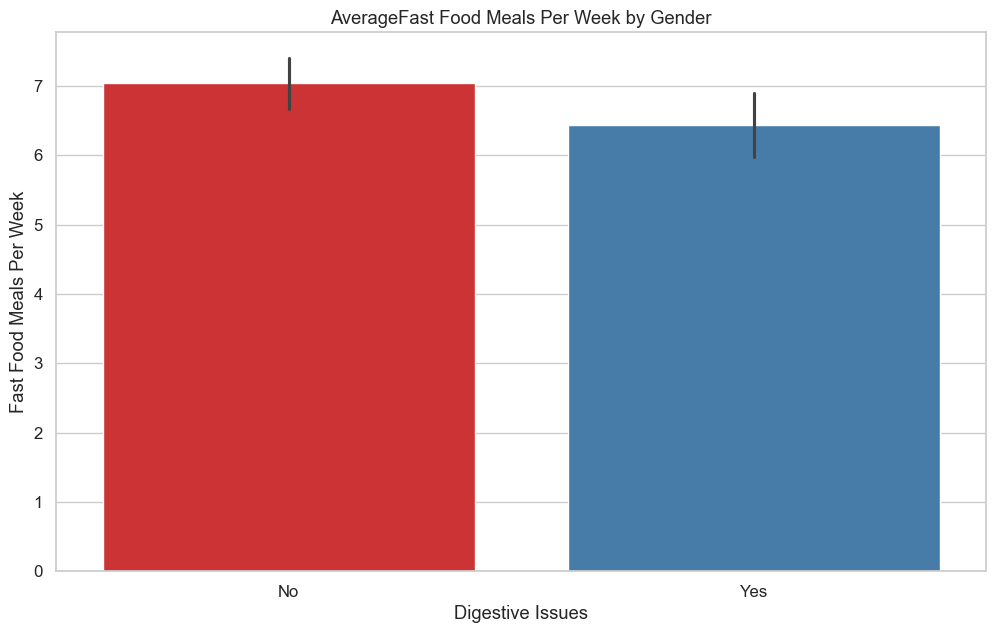

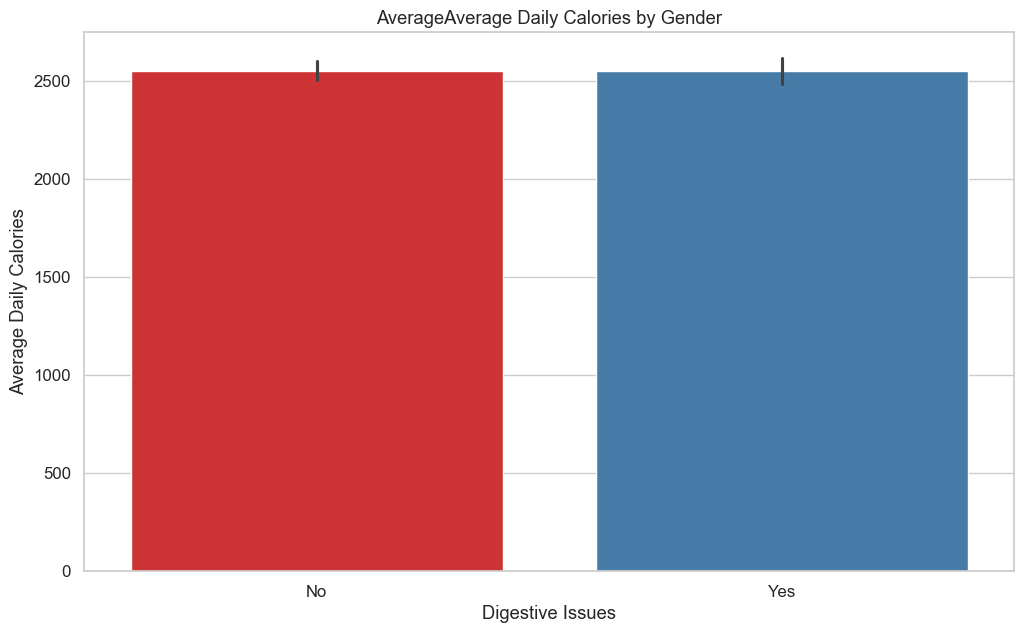

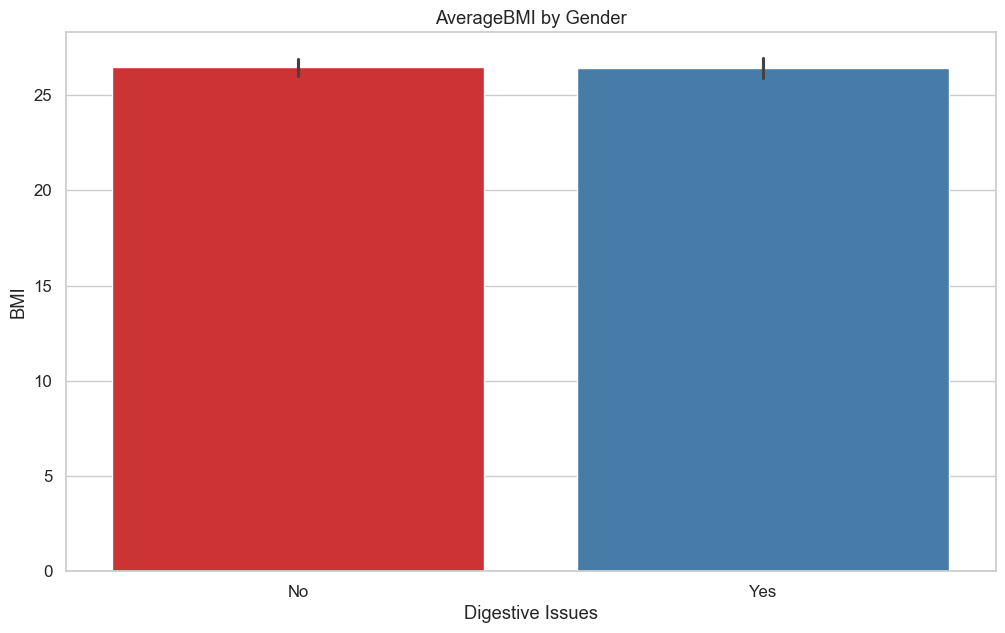

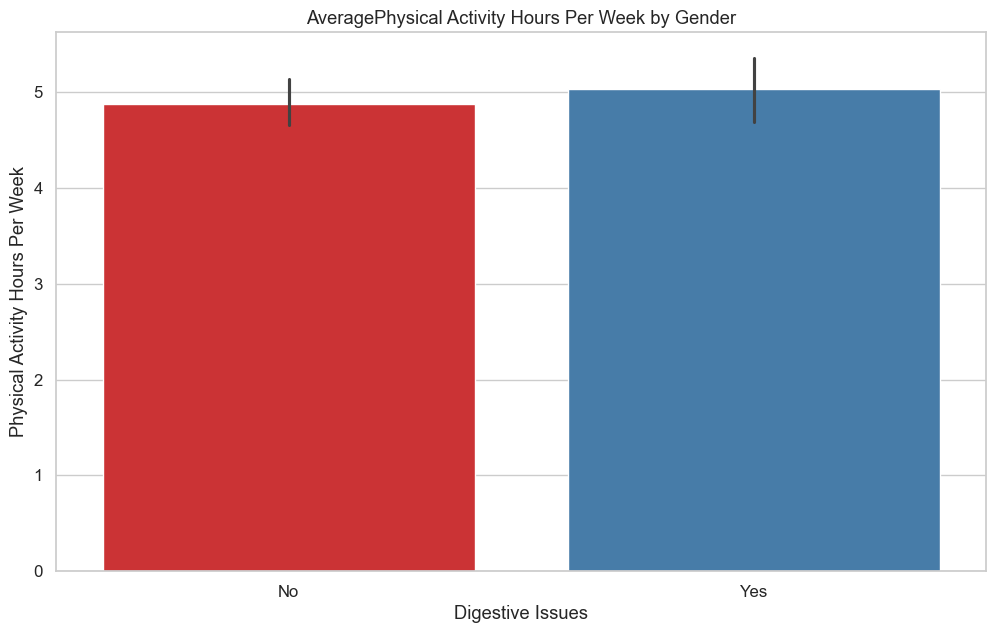

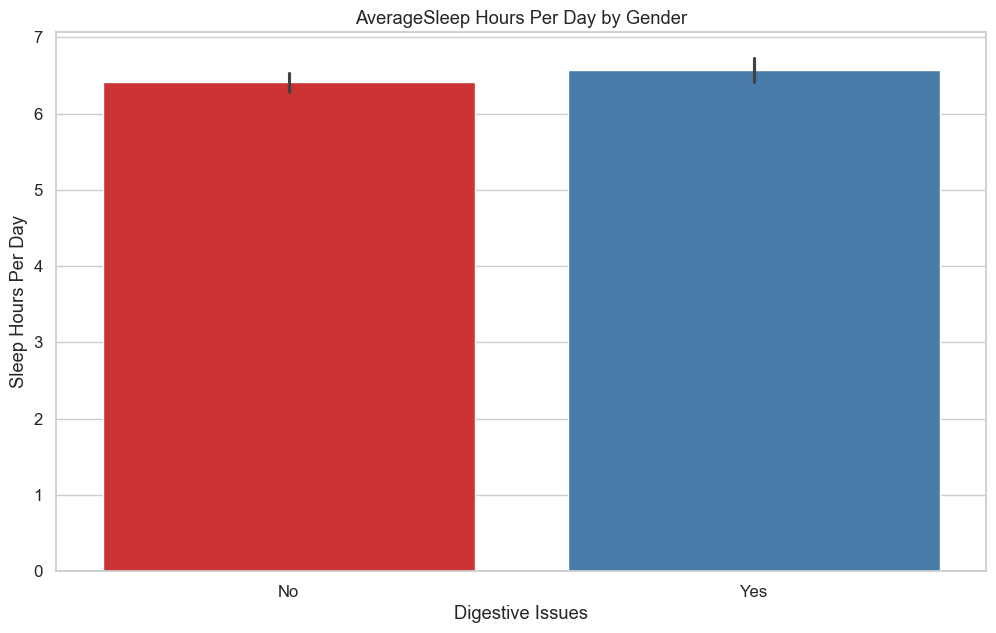

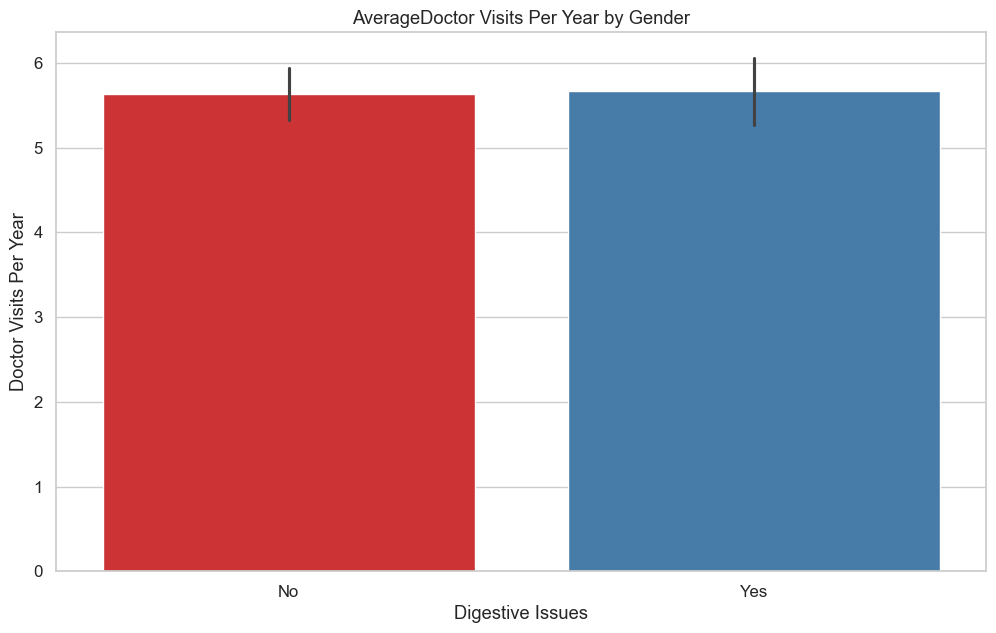

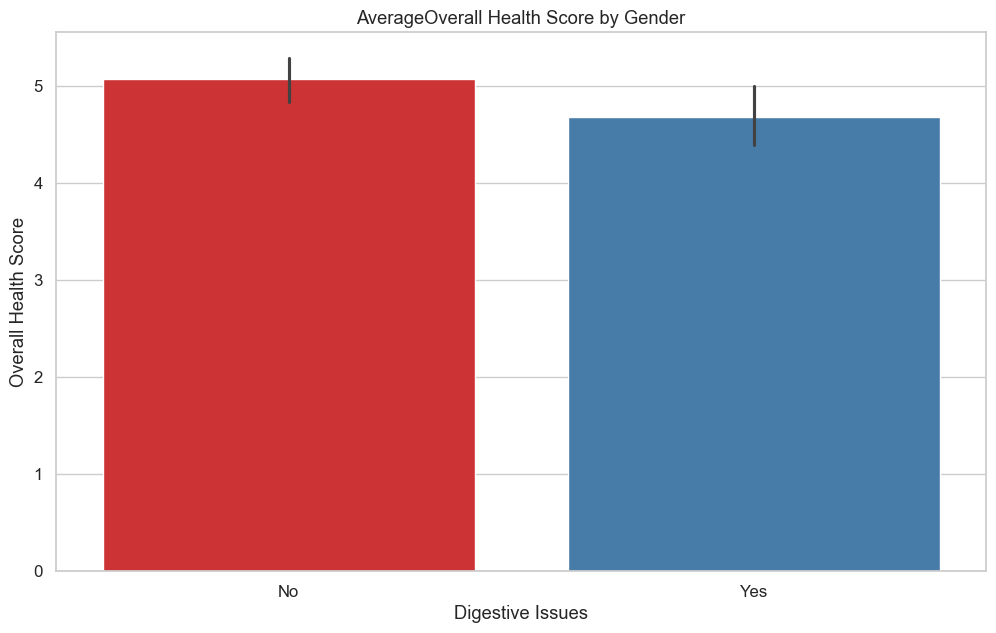

In [30]:

for col in num_target:
    plt.figure()
    sns.barplot(data=df,x='Digestive_Issues',y=col,palette='Set1')
    plt.title(f'Average{col.replace("_"," ")} by Gender')
    plt.xlabel('Digestive Issues')
    plt.ylabel(col.replace('_',' '))

    plt.show()

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   Age                               800 non-null    int64   
 1   Gender                            800 non-null    category
 2   Fast_Food_Meals_Per_Week          800 non-null    int64   
 3   Average_Daily_Calories            800 non-null    int64   
 4   BMI                               800 non-null    float64 
 5   Physical_Activity_Hours_Per_Week  800 non-null    float64 
 6   Sleep_Hours_Per_Day               800 non-null    float64 
 7   Energy_Level_Score                800 non-null    int64   
 8   Digestive_Issues                  800 non-null    category
 9   Doctor_Visits_Per_Year            800 non-null    int64   
 10  Overall_Health_Score              800 non-null    int64   
dtypes: category(2), float64(3), int64(6)
memory usage: 58.1 KB


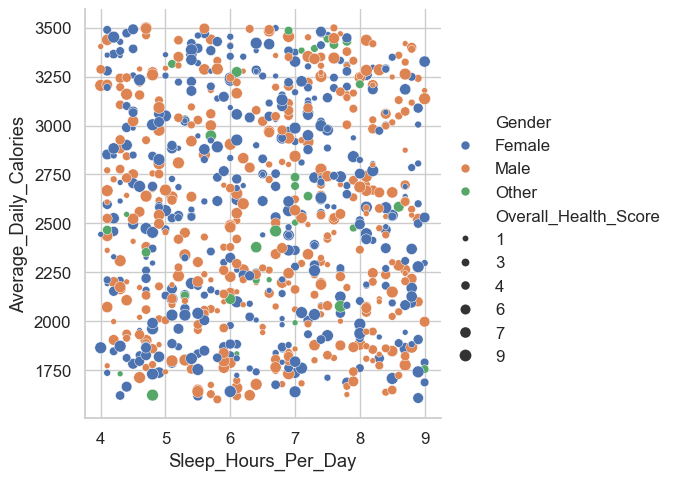

In [32]:
sns.relplot(data=df,x='Sleep_Hours_Per_Day',y='Average_Daily_Calories',hue='Gender',size='Overall_Health_Score')

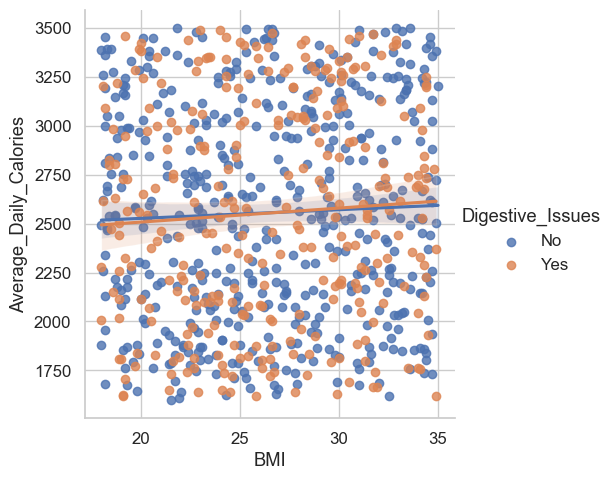

In [33]:
g = sns.lmplot(
    data=df,
    x="BMI", y="Average_Daily_Calories", hue="Digestive_Issues",
    height=5
)